<a href="https://colab.research.google.com/github/gisele-mgs/especializacacin/blob/main/series_temporais_cooperacaobr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### GDELT (global database of events language and tone)

> Adicionar aspas


## Série de eventos de cooperação do Brasil

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/series
!ls

/content/drive/MyDrive/series
all_variables_BR.csv  BR.csv  series.ipynb


In [ ]:
!pip install numpy==1.26.4
!pip install pmdarima==2.0.4


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 39.8 MB/s eta 0:00:00


## 1. importação de bibliotecas e base de dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pmdarima as pm

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# lib to use the acf and pcf correlations
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae

from pmdarima.arima import auto_arima, arima
# from pmdarima.utils import tsdisplay
from pmdarima.preprocessing import BoxCoxEndogTransformer
from pmdarima.model_selection import train_test_split
from pmdarima.pipeline import Pipeline


In [ ]:
brevent = pd.read_csv('BR.csv')
brevent

,Unnamed: 0,ActionGeo_CountryCode,MonthYear,EventBaseCode,eventcount
0,0,BR,200803,10,798
1,1,BR,200804,10,976
2,2,BR,200805,10,1179
3,3,BR,200806,10,1099
4,4,BR,200807,10,1159
...,...,...,...,...,...
17929,2493,BR,202110,190,244
17930,2494,BR,202110,191,11
17931,2495,BR,202110,192,44
17932,2496,BR,202110,193,123


In [ ]:
# 50 Engage in diplomatic cooperation
# 57 Sign formal agreement
#60 Engage in material cooperation
# 61 Cooperate economically
#62 Cooperate militarily

# 63 Engage in judicial cooperation
# 64 Share intelligence or information


In [ ]:
code = [50, 57, 60,61,62,63,64]

In [ ]:
brcop= brevent[brevent['EventBaseCode'].isin(code)]
brcop

,Unnamed: 0,ActionGeo_CountryCode,MonthYear,EventBaseCode,eventcount
4890,4890,BR,200803,50,35
4891,4891,BR,200804,50,35
4892,4892,BR,200805,50,43
4893,4893,BR,200806,50,50
4894,4894,BR,200807,50,70
...,...,...,...,...,...
17862,2426,BR,202110,60,144
17863,2427,BR,202110,61,166
17864,2428,BR,202110,62,36
17865,2429,BR,202110,63,3


In [ ]:
brcop["Data"] = pd.to_datetime(brcop["MonthYear"], format="%Y%m")


/tmp/ipython-input-3446155860.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brcop["Data"] = pd.to_datetime(brcop["MonthYear"], format="%Y%m")


In [ ]:
# extrair ano/mês
brcop['year'] = brcop['Data'].dt.year
brcop['month'] = brcop['Data'].dt.month

/tmp/ipython-input-1927295039.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brcop['year'] = brcop['Data'].dt.year
/tmp/ipython-input-1927295039.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brcop['month'] = brcop['Data'].dt.month


In [ ]:
brcop

,Unnamed: 0,ActionGeo_CountryCode,MonthYear,EventBaseCode,eventcount,Data,year,month
4890,4890,BR,200803,50,35,2008-03-01,2008,3
4891,4891,BR,200804,50,35,2008-04-01,2008,4
4892,4892,BR,200805,50,43,2008-05-01,2008,5
4893,4893,BR,200806,50,50,2008-06-01,2008,6
4894,4894,BR,200807,50,70,2008-07-01,2008,7
...,...,...,...,...,...,...,...,...
17862,2426,BR,202110,60,144,2021-10-01,2021,10
17863,2427,BR,202110,61,166,2021-10-01,2021,10
17864,2428,BR,202110,62,36,2021-10-01,2021,10
17865,2429,BR,202110,63,3,2021-10-01,2021,10


In [ ]:
brserie = brcop[["Data", "EventBaseCode", "eventcount"]]
brserie

,Data,EventBaseCode,eventcount
4890,2008-03-01,50,35
4891,2008-04-01,50,35
4892,2008-05-01,50,43
4893,2008-06-01,50,50
4894,2008-07-01,50,70
...,...,...,...
17862,2021-10-01,60,144
17863,2021-10-01,61,166
17864,2021-10-01,62,36
17865,2021-10-01,63,3


Evolução dos eventos por código (sem agrupamento)

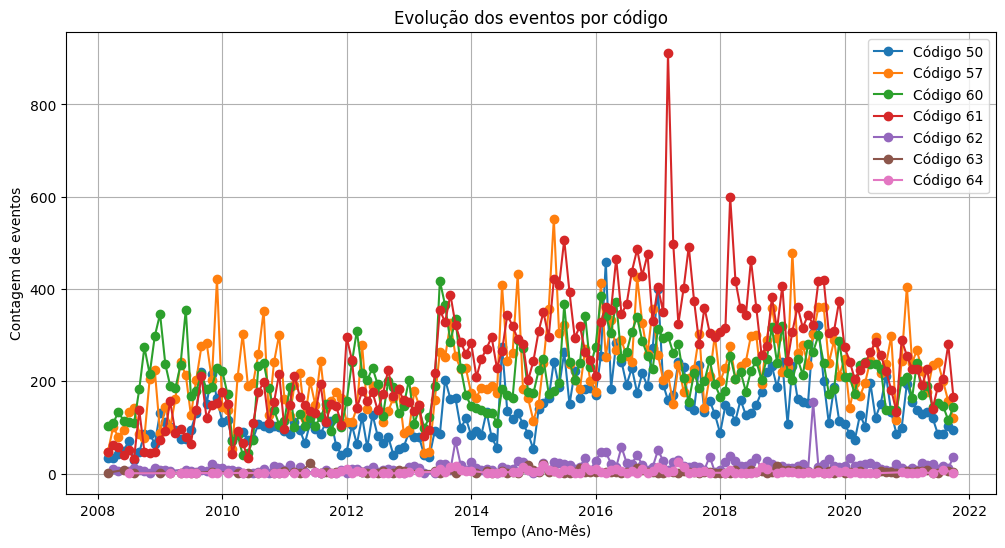

In [ ]:
plt.figure(figsize=(12,6))
for code, grupo in brserie.groupby("EventBaseCode"):
    plt.plot(grupo["Data"], grupo["eventcount"], marker="o", label=f"Código {code}")

plt.title("Evolução dos eventos por código")
plt.xlabel("Tempo (Ano-Mês)")
plt.ylabel("Contagem de eventos")
plt.legend()
plt.grid(True)
plt.show()

# 2. Pré processamento e Metodologia de Box & Jenkins

In [ ]:
brserietotal = (brserie.groupby('Data')['eventcount']
                  .sum()
                  .asfreq('MS')  # garantir frequência mensal
                  .fillna(0))    # lidar com meses sem eventos

In [ ]:
brserietotal

,eventcount
Data,
2008-03-01,234
2008-04-01,320
2008-05-01,319
2008-06-01,308
2008-07-01,374
...,...
2021-06-01,663
2021-07-01,682
2021-08-01,665


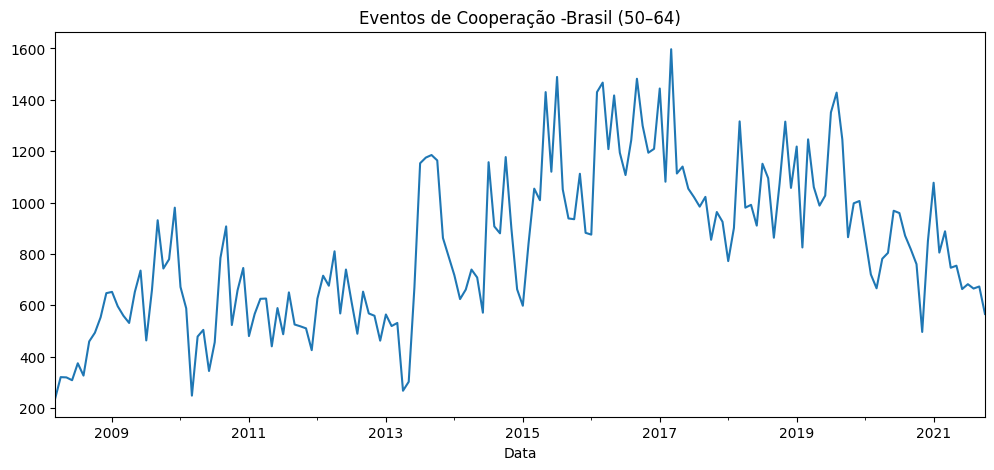

count     164.000000
mean      826.573171
std       301.454451
min       234.000000
25%       594.250000
50%       797.000000
75%      1051.750000
max      1597.000000
Name: eventcount, dtype: float64


In [ ]:
brserietotal.plot(figsize=(12,5), title="Eventos de Cooperação -Brasil (50–64)")
plt.show()

print(brserietotal.describe())

<Axes: xlabel='Data'>

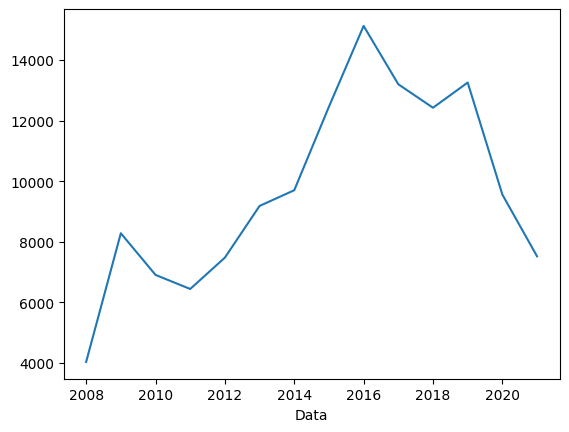

In [ ]:
df_year = brserietotal.groupby(brserietotal.index.year).sum()
df_year.plot()

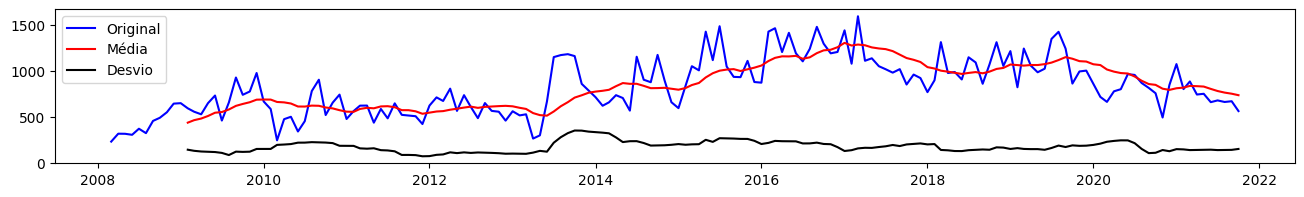

In [ ]:
m_m = brserietotal.rolling(window=12).mean()
m_std = brserietotal.rolling(window=12).std()
plt.figure(figsize=(16,2))
orig = plt.plot(brserietotal, color='blue',label='Original')
mean = plt.plot(m_m, color='red',label='Média')
std = plt.plot(m_std, color='black',label='Desvio')
plt.legend(loc='best')
plt.show()

Estimativa e Eliminação de Tendência

### média móvel

In [ ]:
k = 12  # janela de 12 meses
media_mov = brserietotal.rolling(window=k).mean()

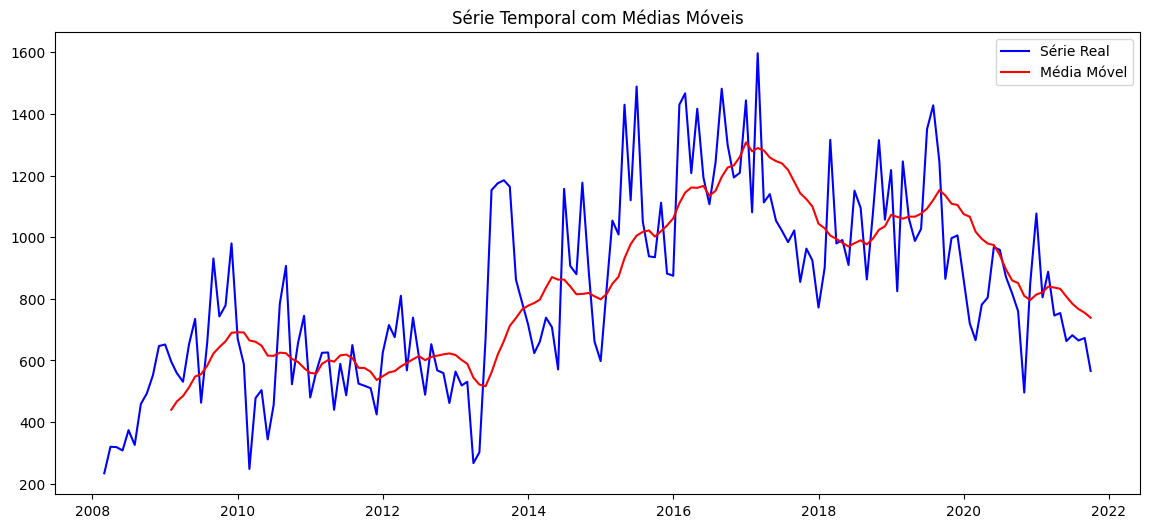

In [ ]:

rolling = brserietotal.rolling(window=3)
rolling_mean = rolling.mean()
# Plot da série original e das médias móveis
plt.figure(figsize=(14,6))
plt.plot(brserietotal, label='Série Real', color='blue')
plt.plot(media_mov, color='red', label='Média Móvel')

plt.title("Série Temporal com Médias Móveis")
plt.legend(loc='best')
plt.show()


### Suavização Exponecial

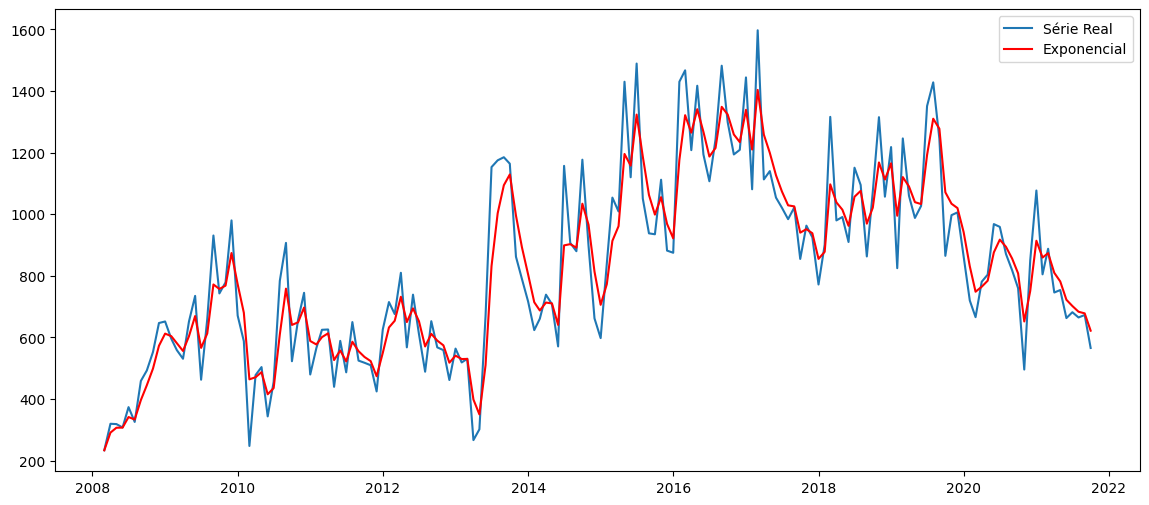

In [ ]:
rolling =  brserietotal.ewm(alpha = 0.5)
rolling_mean = rolling.mean()
plt.figure(figsize=(14,6))

plt.plot(brserietotal, label='Série Real')
plt.plot(rolling_mean,color='red', label='Exponencial')
plt.legend(loc='best')
plt.show()

### Eliminando a tendência

In [ ]:
dados_sazonalidade_ruido = brserietotal - rolling_mean  # Série - componente de tendência

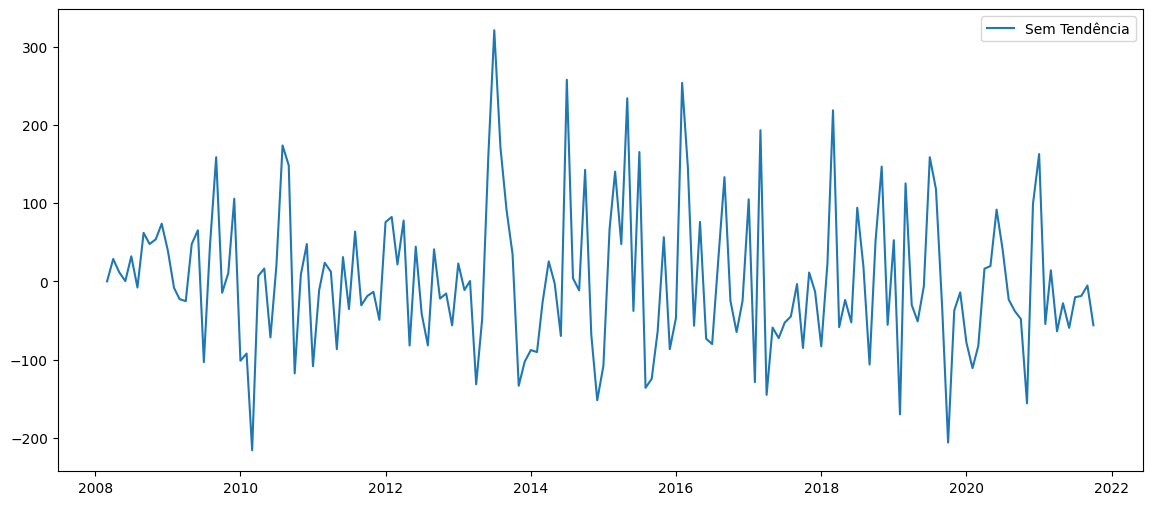

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(dados_sazonalidade_ruido, label='Sem Tendência')
plt.legend(loc='best')
plt.show()

### Eliminação de Tendência por Diferenciação

In [ ]:
brserietotal.shift()

,eventcount
Data,
2008-03-01,NaN
2008-04-01,234.0
2008-05-01,320.0
2008-06-01,319.0
2008-07-01,308.0
...,...
2021-06-01,754.0
2021-07-01,663.0
2021-08-01,682.0


In [ ]:
dados_diff = brserietotal - brserietotal.shift()  #Subtrai a série por ela mesma com um retardo -1

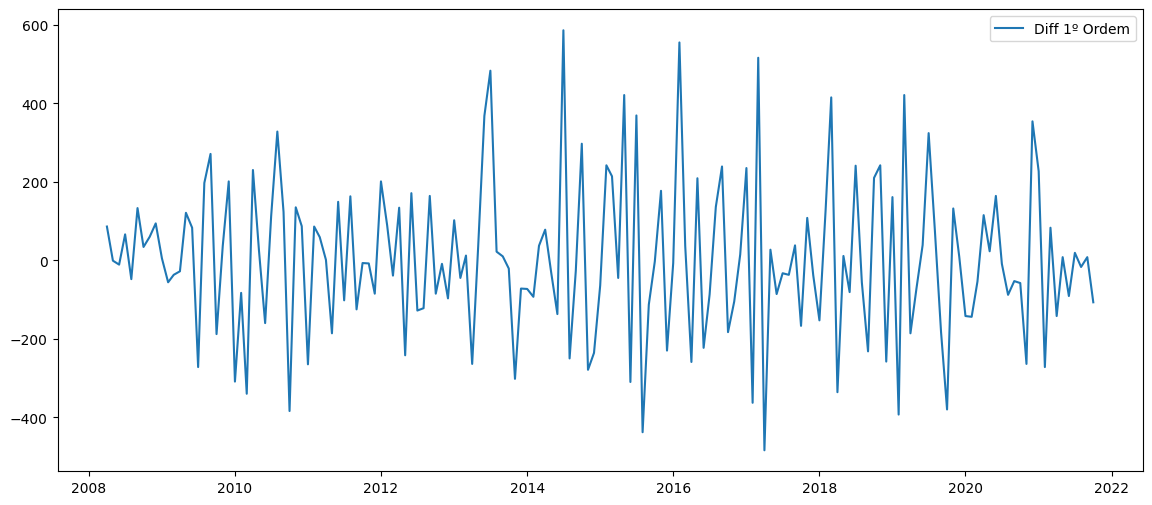

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(dados_diff, label='Diff 1º Ordem')
plt.legend(loc='best')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(dados_diff.dropna())
print(f"ADF: {result[0]}, p-value: {result[1]}")

ADF: -8.058588004164795, p-value: 1.6665028531657818e-12


### Autocorrelação

* Correlação negativa:

Quando os valores das observações tendem a se alternar acima e abaixo de uma média, o coeficiente de correlação também tende a se alternar;

O valor de r1 será negativo enquanto o valor de r2 será positivo, já que as observações defasadas de 2 períodos (lags) tendem a estar do mesmo lado da média;

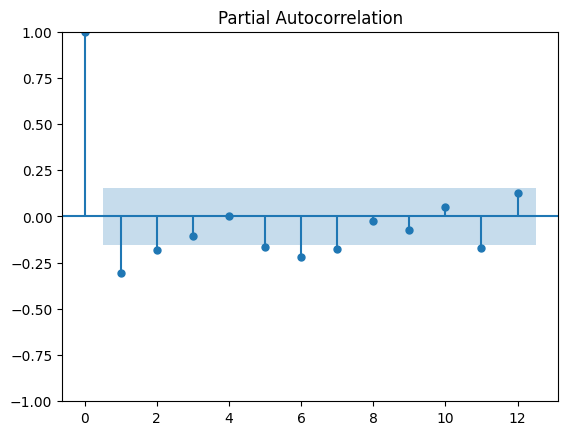

In [ ]:
plot_pacf(dados_diff.dropna(), lags=12)
plt.show()

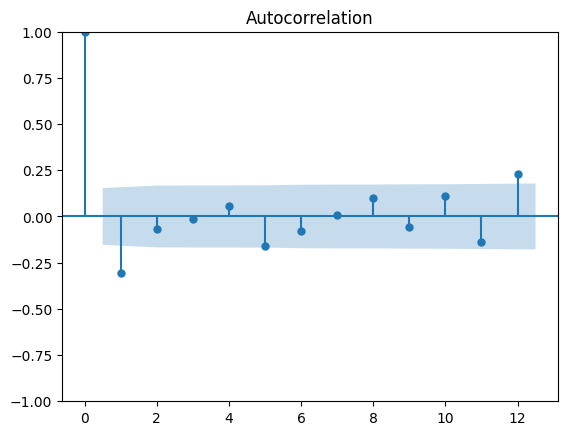

In [ ]:

plot_acf(dados_diff.dropna(), lags=12)
plt.show()



### Estimação e Eliminação da Sazonalidade

In [ ]:
brevent_sr = dados_sazonalidade_ruido

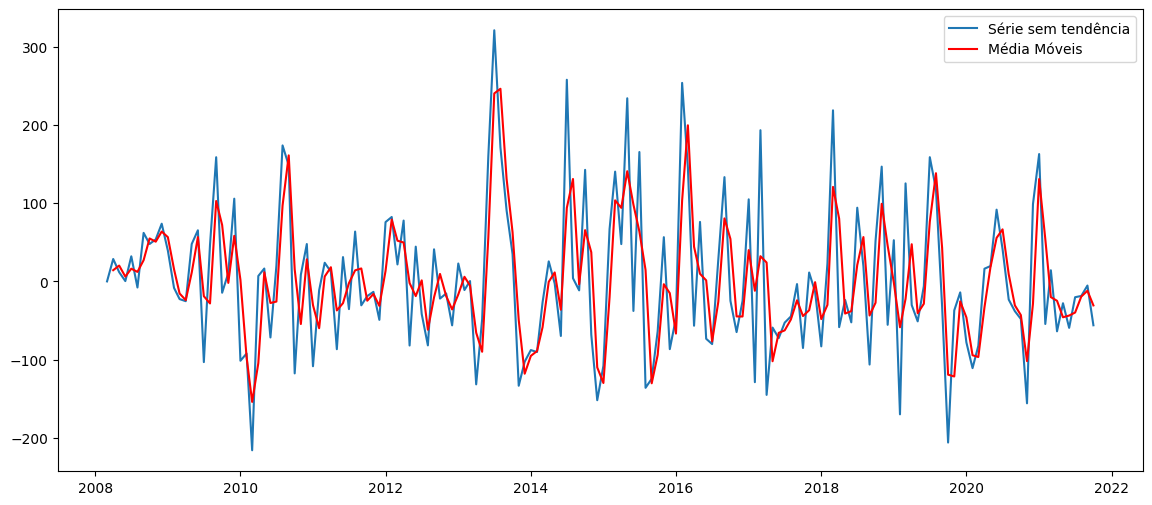

In [ ]:
#Aplica média móveis na série sem a tendência
brevent_sr

rolling = brevent_sr.rolling(window=2)
rolling_mean = rolling.mean()
# plot original and transformed dataset
plt.figure(figsize=(14,6))

plt.plot(brevent_sr, label='Série sem tendência')
plt.plot(rolling_mean,color='red', label='Média Móveis')
plt.legend(loc='best')
plt.show()

In [ ]:
brevent_sruido = brevent_sr - rolling_mean #Elimina o componente de sazonalidade

### Ruído

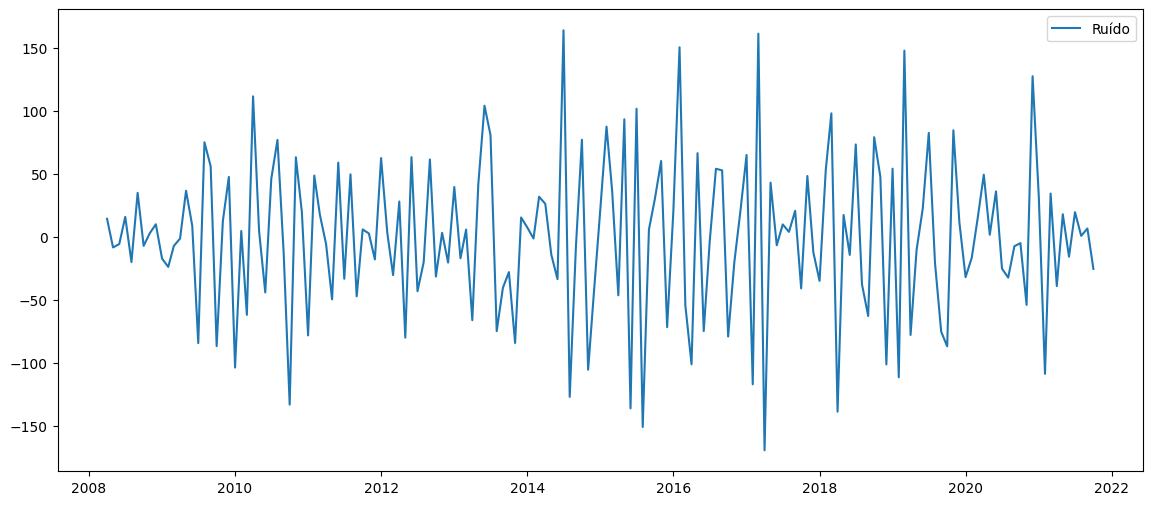

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(brevent_sruido, label='Ruído')
plt.legend(loc='best')
plt.show()

In [ ]:
import statsmodels.tsa.api as smt

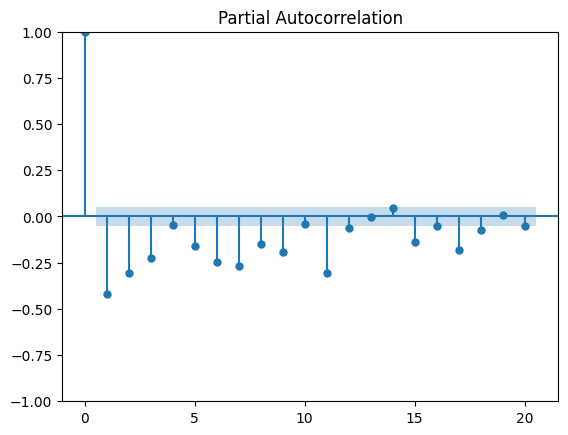

<Figure size 1400x600 with 0 Axes>

In [ ]:
brevent_sruido.dropna(inplace=True) # retira os NaN
smt.graphics.plot_pacf(brevent_sruido, lags=20, alpha=0.5)
plt.figure(figsize=(14,6))
plt.show()

### Definição de validação, treino e teste

In [ ]:
brdiff = dados_diff.dropna()

In [ ]:
brdiff

,eventcount
Data,
2008-04-01,86.0
2008-05-01,-1.0
2008-06-01,-11.0
2008-07-01,66.0
2008-08-01,-48.0
...,...
2021-06-01,-91.0
2021-07-01,19.0
2021-08-01,-17.0


In [ ]:
n = len(brdiff)

train_size = int(n * 0.5)
val_size   = int(n * 0.25)
test_size   = int(n * 0.25)

train = brdiff.iloc[:train_size]
val   = brdiff.iloc[train_size:train_size+val_size]
test  = brdiff.iloc[train_size:train_size+test_size]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(0, 1))
min_max_scaler.fit(brdiff.iloc[:train_size].values.reshape(-1, 1))

serie_normalized = min_max_scaler.transform(brdiff.values.reshape(-1, 1)).flatten()


# AR

In [ ]:
model_AR = pm.arima.ARIMA(order=(1,0,0))
model_AR.fit(train)
m=12

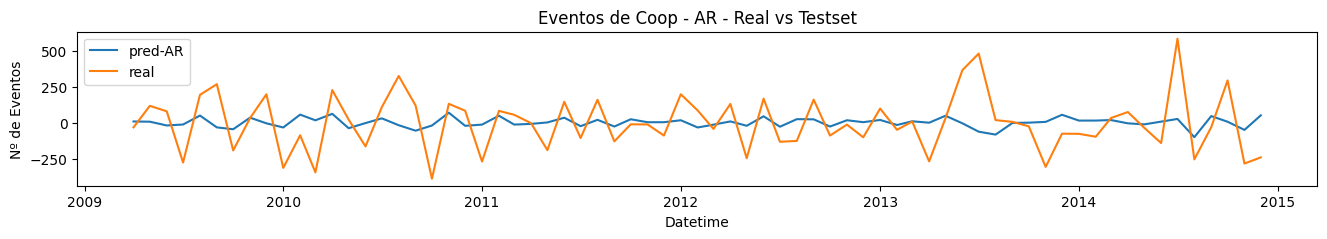

In [ ]:
predictions_train_AR = model_AR.predict_in_sample()
plt.figure(figsize=(16, 2))
plt.plot(predictions_train_AR[m:], label='pred-AR')
plt.plot(train[m:], label='real')
plt.title("Eventos de Coop - AR - Real vs Testset")
plt.xlabel("Datetime")
plt.ylabel("Nº de Eventos")
plt.legend()
plt.legend()
plt.show()

In [ ]:
predictions_train_AR = pd.Series(train, index=train.index)
predictions_train_AR

,eventcount
Data,
2008-04-01,86.0
2008-05-01,-1.0
2008-06-01,-11.0
2008-07-01,66.0
2008-08-01,-48.0
...,...
2014-08-01,-250.0
2014-09-01,-27.0
2014-10-01,297.0


In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
def forecast_one_step():
    fc = model_AR.predict(n_periods=1, return_conf_int=False)
    return fc.tolist()[0]
    # np.asarray(conf_int).tolist()[0])

forecasts = []
# confidence_intervals = []

for new_ob in test:
    fc = forecast_one_step()
    forecasts.append(fc)
    # confidence_intervals.append(conf)

    # Updates the existing model with a small number of MLE steps
    model_AR.update(new_ob)

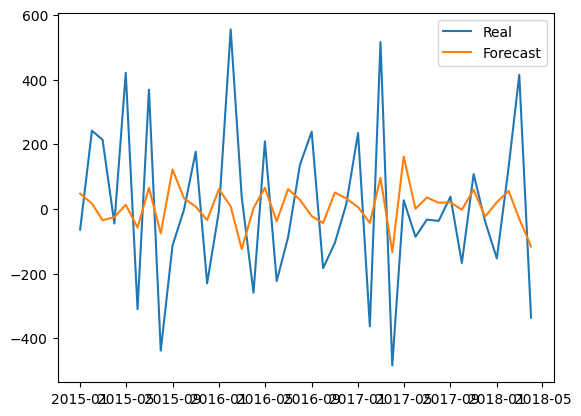

In [ ]:
forecasts = pd.Series(forecasts, index=test.index)  # <- usa a lista de previsões
plt.plot(test, label='Real')
plt.plot(forecasts, label='Forecast')
plt.legend()
plt.show()


In [ ]:
m = 12

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error



mse_value = mean_squared_error(test, forecasts)
mae_value = mean_absolute_error(test, forecasts)
mape_value = mean_absolute_percentage_error(test, forecasts)

print("teste - MAPE:", mape_value)

print("Test MSE: %.10f" % mse_value)
print("Test MAE: %.10f" % mae_value)

teste - MAPE: 1.6738879176775092
Test MSE: 52530.5857135565
Test MAE: 189.6659131451


# ARMA

In [ ]:
model_ARMA = pm.arima.ARIMA(order=(1,0,1))  # p=1, d=0 (estacionário), q=1
model_ARMA.fit(train)

ARIMA(order=(1, 0, 1))

In [ ]:
# --- Previsão one-step para teste ---
forecasts = []
for new_ob in test:
    fc = model_ARMA.predict(n_periods=1)[0]
    forecasts.append(fc)
    model_ARMA.update(new_ob)

forecasts = pd.Series(forecasts, index=test.index)

In [ ]:
mse_value = mean_squared_error(test, forecasts)
mae_value = mean_absolute_error(test, forecasts)
mape_value = mean_absolute_percentage_error(test, forecasts)

print("Test MAPE:", mape_value)
print("Test MSE:", mse_value)
print("Test MAE:", mae_value)

Test MAPE: 1.4568111226141744
Test MSE: 50187.26017700615
Test MAE: 178.43353792506377


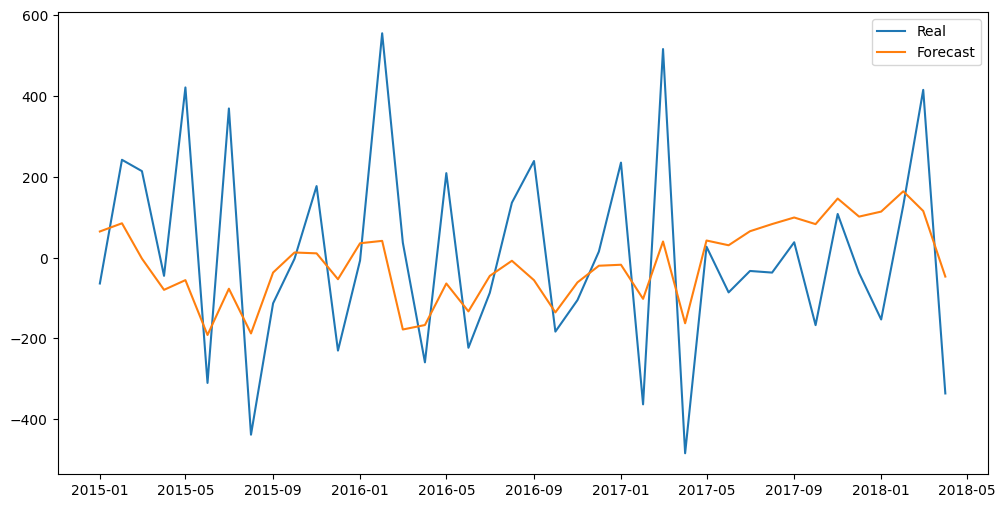

In [ ]:
# --- Plot teste ---
plt.figure(figsize=(12,6))
plt.plot(test, label='Real')
plt.plot(forecasts, label='Forecast')
plt.legend()
plt.show()

# **usando ARIMA**

In [ ]:
from statsmodels.tsa.stattools import adfuller


In [ ]:
dados_diff

,eventcount
Data,
2008-03-01,NaN
2008-04-01,86.0
2008-05-01,-1.0
2008-06-01,-11.0
2008-07-01,66.0
...,...
2021-06-01,-91.0
2021-07-01,19.0
2021-08-01,-17.0


In [ ]:
result = adfuller(brdiff)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])

ADF Statistic: -8.058588004164795
p-value: 1.6665028531657818e-12
Critical Values: {'1%': -3.4729792729247793, '5%': -2.8802520918255534, '10%': -2.5767469641683105}


In [ ]:
# Teste de estacionariedade novamente
adf_result = adfuller(brserietotal)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -2.0234621962273813
p-value: 0.2763814272624568


<Axes: xlabel='Data'>

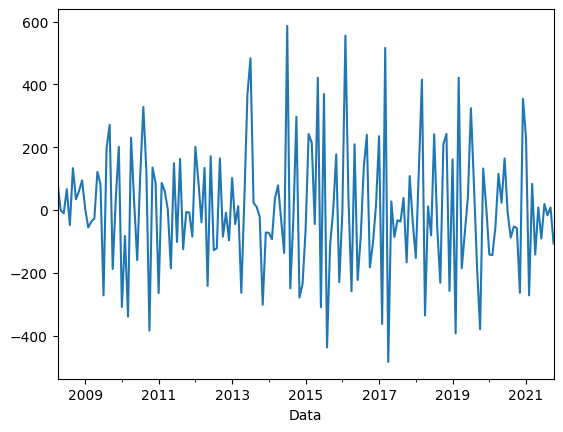

In [ ]:
brdiff.plot()

In [ ]:
brdiff

,eventcount
Data,
2008-04-01,86.0
2008-05-01,-1.0
2008-06-01,-11.0
2008-07-01,66.0
2008-08-01,-48.0
...,...
2021-06-01,-91.0
2021-07-01,19.0
2021-08-01,-17.0


<Axes: xlabel='Data'>

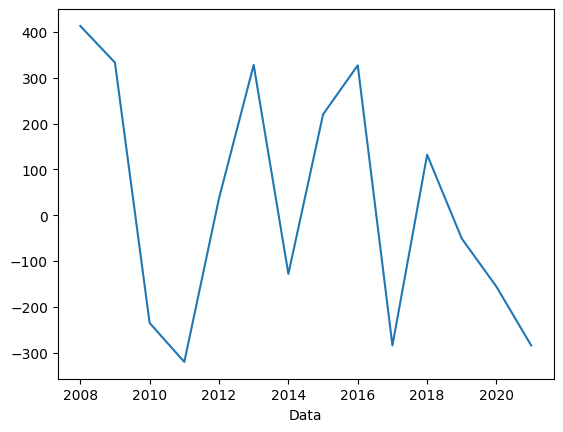

In [ ]:
ano = brdiff.groupby(brdiff.index.year).sum()
ano.plot()

In [ ]:
from pmdarima import arima
from pmdarima import datasets
from pmdarima import utils

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


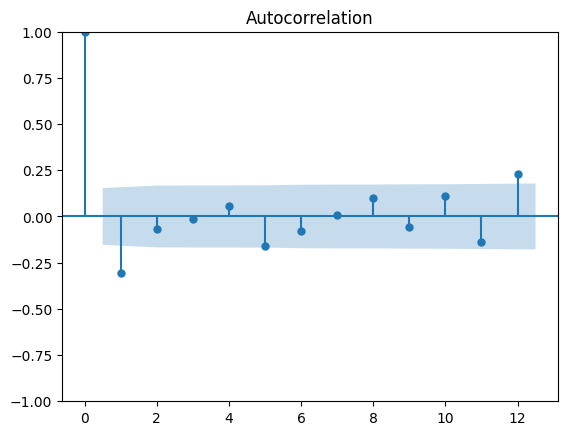

In [ ]:
# to use the acf
plot_acf(brdiff, lags=12)
plt.show()


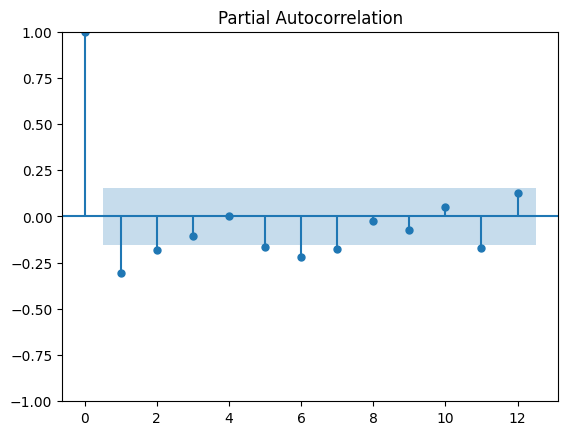

In [ ]:
# to use the pacf
plot_pacf(brdiff, lags=12)
plt.show()

In [ ]:
# Test for stationarity using the Augmented Dickey-Fuller (ADF) test
from statsmodels.tsa.stattools import adfuller
result = adfuller(brserietotal)

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] <= 0.05:
    print('The data is stationary.')
else:
    print('The data is non-stationary.')


ADF Statistic: -2.0234621962273813
p-value: 0.2763814272624568
Critical Values:
	1%: -3.473
	5%: -2.880
	10%: -2.577
The data is non-stationary.


In [ ]:
# 1) Split na série original (garantir test=12)
n = len(brserietotal)
test_size = 12
if n <= test_size:
    raise ValueError("Série muito curta.")

test = brserietotal.iloc[-test_size:]
rest = brserietotal.iloc[:-test_size]

# dividir rest em train/val (70/30 do resto)
rest_n = len(rest)
train_size = int(rest_n * 0.7)

train = rest.iloc[:train_size]
val   = rest.iloc[train_size:]

print(f"n={n} -> train={len(train)}, val={len(val)}, test={len(test)}")


n=164 -> train=106, val=46, test=12


In [ ]:
model_ARIMA = pm.arima.ARIMA(order=(2,1,1))
model_ARIMA.fit(train)

ARIMA(order=(2, 1, 1))

In [ ]:
def forecast_one_step():
    fc = model_ARIMA.predict(n_periods=1, return_conf_int=False)
    return fc.tolist()[0]

forecasts_ARIMA = []
for new_ob in test:
    fc = forecast_one_step()
    forecasts_ARIMA.append(fc)
    # confidence_intervals.append(conf)

    # Updates the existing model with a small number of MLE steps
    model_ARIMA.update(new_ob)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_value = mean_squared_error(test, forecasts_ARIMA)
mae_value = mean_absolute_error(test, forecasts_ARIMA)
mape_test = mean_absolute_percentage_error(test, forecasts_ARIMA)

print("teste - MAPE:", mape_test)

print("Test MSE: %.10f" % mse_value)
print("Test MAE: %.10f" % mae_value)


teste - MAPE: 0.3320579380125449
Test MSE: 70722.4599482913
Test MAE: 212.4541678142


In [ ]:
residuals = model_ARIMA.resid()  # note os parênteses


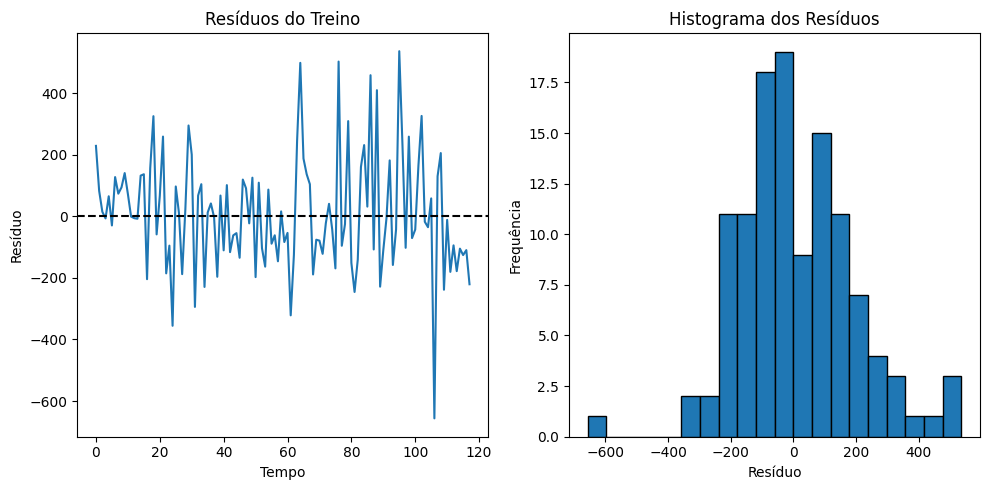

In [ ]:
# Resíduos ao longo do tempo
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(residuals)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Resíduos do Treino")
plt.xlabel("Tempo")
plt.ylabel("Resíduo")

# Histograma dos resíduos
plt.subplot(1,2,2)
plt.hist(residuals, bins=20, edgecolor="black")
plt.title("Histograma dos Resíduos")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [ ]:
test_size = 12
test_plot = brserietotal.iloc[-test_size:]  # sempre pegar os últimos 12


In [ ]:
forecasts_ARIMA_series = pd.Series(forecasts_ARIMA, index=test_plot.index)


In [ ]:
test_plot = brserietotal.iloc[-test_size:]  # últimos 12 pontos


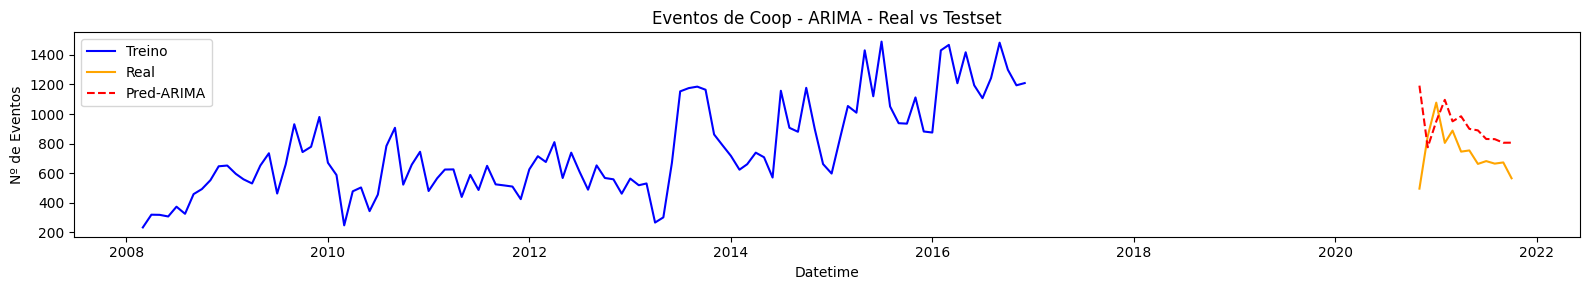

In [ ]:
plt.figure(figsize=(16,3))  # largura maior, altura menor como na imagem
plt.plot(train.index, train, label='Treino', color='blue')
plt.plot(test.index, test, label='Real', color='orange')
plt.plot(forecasts_ARIMA_series.index, forecasts_ARIMA_series, label='Pred-ARIMA', color='red', linestyle='--')

plt.title("Eventos de Coop - ARIMA - Real vs Testset")
plt.xlabel("Datetime")
plt.ylabel("Nº de Eventos")
plt.legend()
plt.tight_layout()
plt.show()


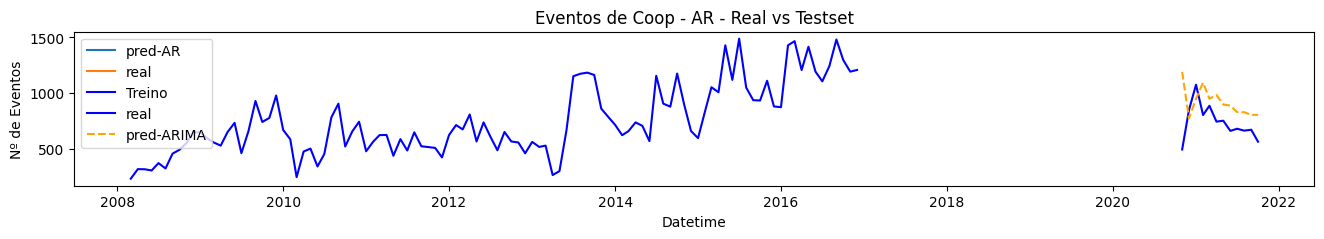

In [ ]:
predictions_train_AR = model_AR.predict_in_sample()
plt.figure(figsize=(16, 2))
plt.plot(forecasts_ARIMA_series[m:], label='pred-AR')
plt.plot(test_plot[m:], label='real')

plt.plot(train.index, train, label='Treino', color='blue')
# Teste real
plt.plot(test_plot.index, test_plot, label='real', color='blue')
# Previsão ARIMA para teste
plt.plot(forecasts_ARIMA_series.index, forecasts_ARIMA_series, label='pred-ARIMA', color='orange', linestyle='--')

plt.xlabel("Tempo")
plt.title("Eventos de Coop - AR - Real vs Testset")
plt.xlabel("Datetime")
plt.ylabel("Nº de Eventos")
plt.legend()
plt.legend()
plt.show()

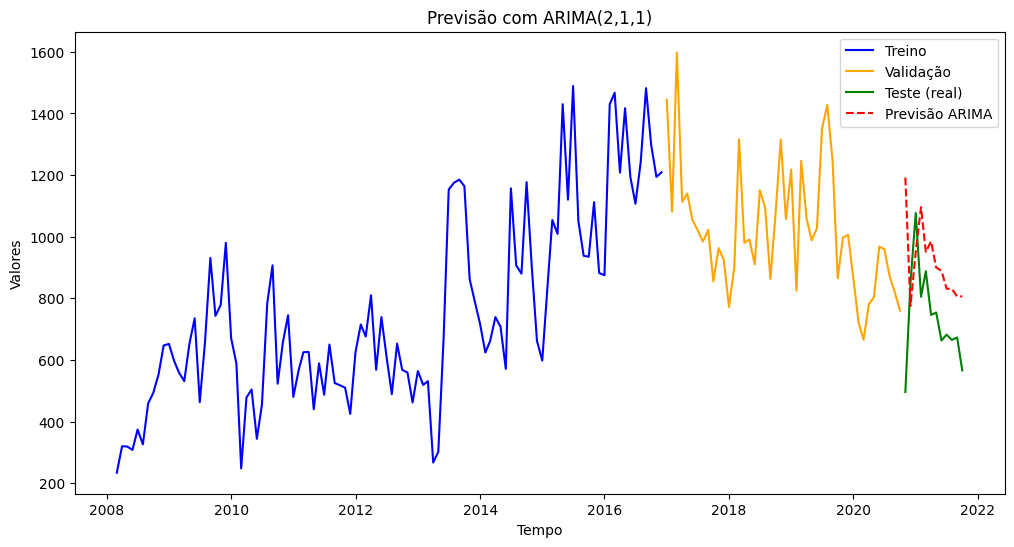

In [ ]:
plt.figure(figsize=(12,6))
plt.title("Previsão com ARIMA(2,1,1)")

# Treino
plt.plot(train.index, train, label='Treino', color='blue')

# Validação (opcional)
plt.plot(val.index, val, label='Validação', color='orange')

# Teste real
plt.plot(test.index, test, label='Teste (real)', color='green')

# Previsão ARIMA para teste
plt.plot(forecasts_ARIMA_series.index, forecasts_ARIMA_series, label='Previsão ARIMA', color='red', linestyle='--')

plt.xlabel("Tempo")
plt.ylabel("Valores")
plt.legend()
plt.show()

## SARIMA

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(train, order=(0,0,1), seasonal_order=(1,0,0,12))
fit = model_sarima.fit(disp=False)
print(fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                          eventcount   No. Observations:                  106
Model:             SARIMAX(0, 0, 1)x(1, 0, [], 12)   Log Likelihood                -736.816
Date:                             Fri, 10 Oct 2025   AIC                           1479.632
Time:                                     20:06:25   BIC                           1487.623
Sample:                                 03-01-2008   HQIC                          1482.871
                                      - 12-01-2016                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6256      0.072      8.694      0.000       0.485       0.767
ar.S.L12       0.9147      

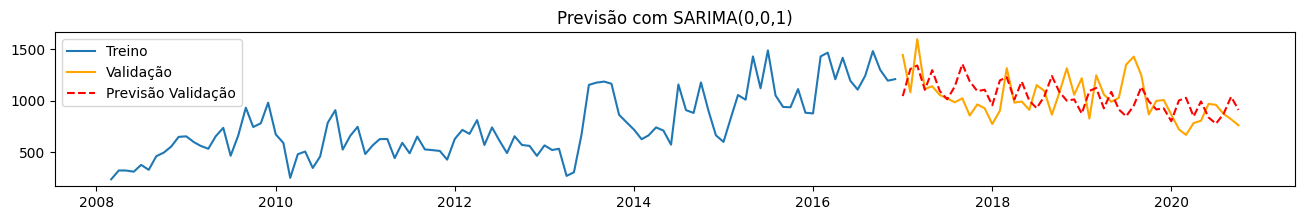

In [ ]:
forecast_val = fit.forecast(steps=len(val))

plt.figure(figsize=(16,2))
plt.title("Previsão com SARIMA(0,0,1)")
plt.plot(train.index, train, label='Treino')
plt.plot(val.index, val, label='Validação', color='orange')
plt.plot(forecast_val.index, forecast_val, label='Previsão Validação', color='red', linestyle='--')
plt.legend()
plt.show()


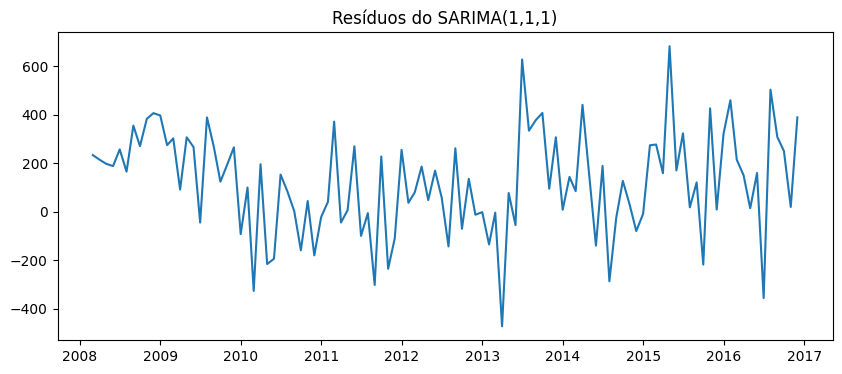

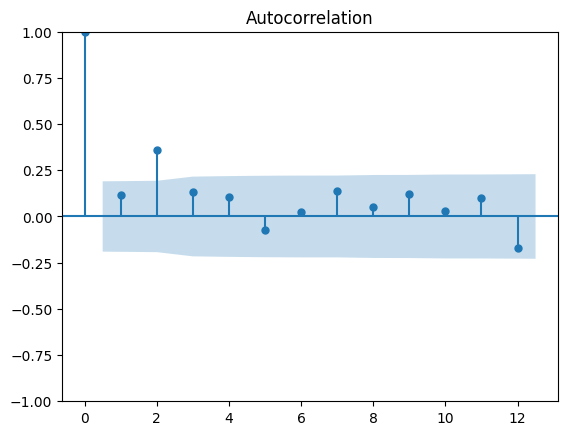

In [ ]:
residuals = fit.resid
plt.figure(figsize=(10,4))

plt.plot(residuals)
plt.title("Resíduos do SARIMA(1,1,1)")
plt.show()

plot_acf(residuals, lags=12)
plt.show()


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# previsões no conjunto de validação
forecast_val = fit.forecast(steps=len(val))

mse_val = mean_squared_error(val, forecast_val)
mape_val = mean_absolute_percentage_error(val, forecast_val)

print("validação - MSE:", mse_val)
print("validação - MAPE:", mape_val)

# refit com treino+validação e previsão no TESTE
final_model = SARIMAX(rest, order=(1,1,1), seasonal_order=(1,0,0,12))
final_fit = final_model.fit(disp=False)
forecast_test = final_fit.forecast(steps=len(test))

mse_test = mean_squared_error(test, forecast_test)
mape_test = mean_absolute_percentage_error(test, forecast_test)

print("teste - MSE:", mse_test)
print("teste - MAPE:", mape_test)


validação - MSE: 48172.78867691259
validação - MAPE: 0.17922120898024582
teste - MSE: 31674.532925599822
teste - MAPE: 0.2251788931415765


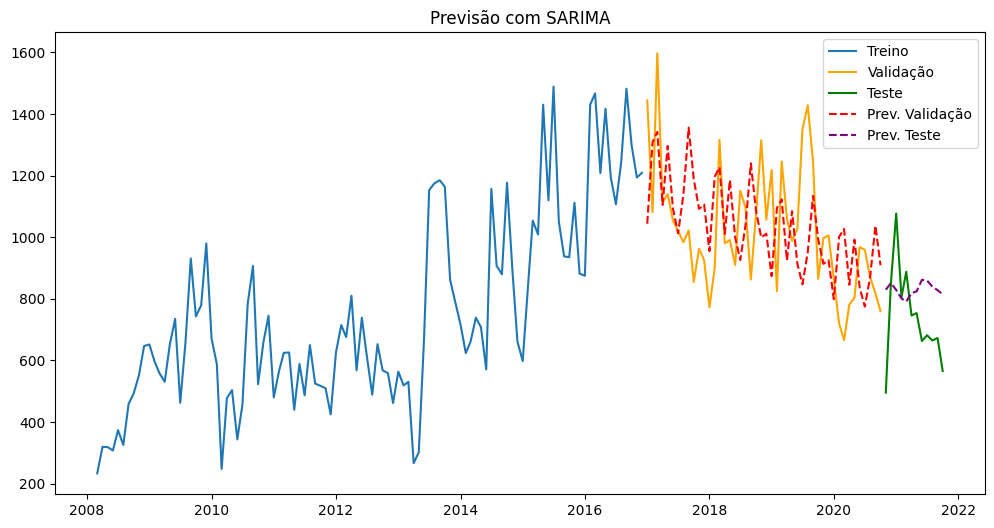

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Treino")
plt.plot(val.index, val, label="Validação", color="orange")
plt.plot(test.index, test, label="Teste", color="green")
plt.plot(forecast_val.index, forecast_val, '--', label="Prev. Validação", color="red")
plt.plot(forecast_test.index, forecast_test, '--', label="Prev. Teste", color="purple")
plt.legend()
plt.title("Previsão com SARIMA")
plt.show()


In [ ]:
# Treino (in-sample)
sarima_forecast_train = sarima_model.predict_in_sample()
sarima_forecast_train = pd.Series(sarima_forecast_train, index=train.index)

# Teste (out-of-sample)
sarima_forecast_test_values = sarima_model.predict(n_periods=len(test))
sarima_forecast_test = pd.Series(sarima_forecast_test_values, index=test.index)

# --- 3️⃣ Resíduos do SARIMA no treino ---
residuals_train = train - sarima_forecast_train


In [ ]:
# Out-of-sample predictions
sarima_forecast_test_values = sarima_model.predict(n_periods=len(test))

# Converte em Series com o índice do teste
sarima_forecast_test = pd.Series(sarima_forecast_test_values, index=test.index)


In [ ]:
# resíduos do modelo (ajuste SARIMA(1,1,1))
residuos = fit.resid

# 1) Teste de Ljung-Box
ljung_box = acorr_ljungbox(residuos, lags=[12], return_df=True)
print("=== Teste de Ljung-Box (lag=12) ===")
print(ljung_box)

=== Teste de Ljung-Box (lag=12) ===
      lb_stat  lb_pvalue
12  28.449884   0.004752


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro, norm

In [ ]:
ljung_box = acorr_ljungbox(fit.resid, lags=[12], return_df=True)

print("=== Teste de Ljung-Box (lag=12) ===")
print(ljung_box)

=== Teste de Ljung-Box (lag=12) ===
      lb_stat  lb_pvalue
12  28.449884   0.004752


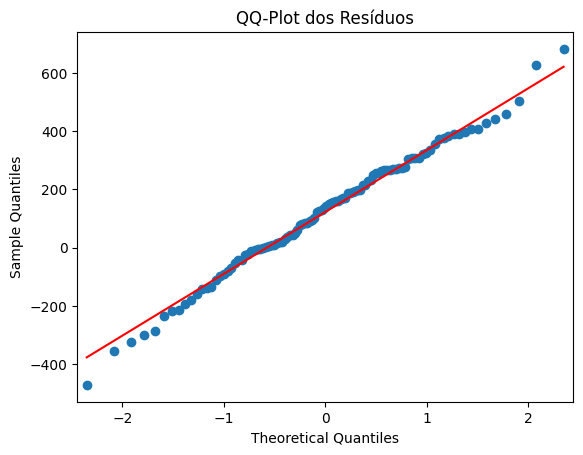

In [ ]:
# 2) QQ-Plot
sm.qqplot(fit.resid, line='s')
plt.title("QQ-Plot dos Resíduos")
plt.show()

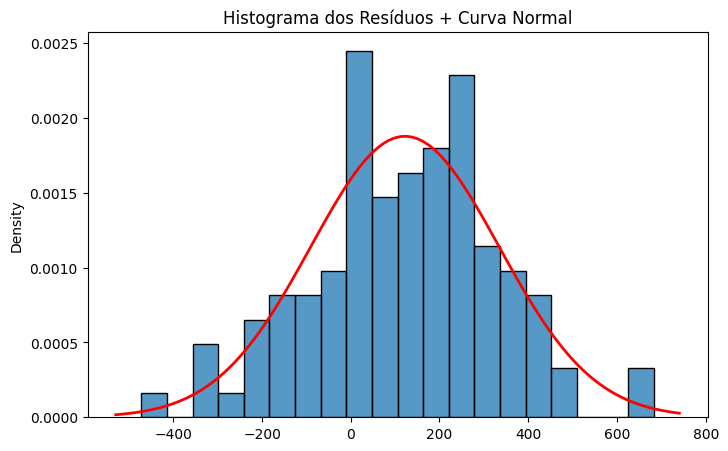

In [ ]:
# 3) Histograma com curva normal
plt.figure(figsize=(8,5))
sns.histplot(residuos, kde=False, bins=20, stat="density")
mu, std = norm.fit(residuos)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2)
plt.title("Histograma dos Resíduos + Curva Normal")
plt.show()

## Com LOG

In [ ]:
# 1. Log-transform do treino
train_log = np.log(train)

# 2. Ajuste do modelo SARIMA nos dados log-transformados
model = SARIMAX(train_log, order=(0,1,1), seasonal_order=(1,1,0,12))
fit = model.fit()

In [ ]:
# 3. Previsão (em log)
forecast_log = fit.forecast(len(test))

# 4. Volta para escala original
forecast = np.exp(forecast_log)

In [ ]:
# 5. Avaliação
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, forecast)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MSE: 865437.9028526453
RMSE: 930.2891501316379
MAPE: 1.282512853936251


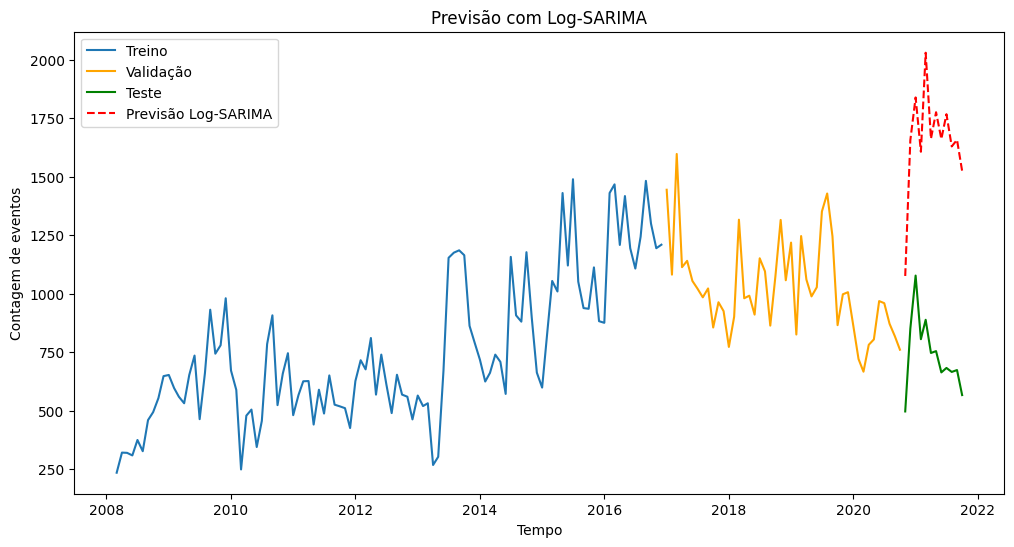

In [ ]:
plt.figure(figsize=(12,6))

# Séries reais

plt.plot(train.index, train, label='Treino')
plt.plot(val.index, val, label='Validação', color='orange')
plt.plot(test.index, test, label='Teste', color='green')
# Previsão no teste
plt.plot(test.index, forecast, label='Previsão Log-SARIMA', color='red', linestyle='--')

plt.title("Previsão com Log-SARIMA")
plt.xlabel("Tempo")
plt.ylabel("Contagem de eventos")
plt.legend()
plt.show()


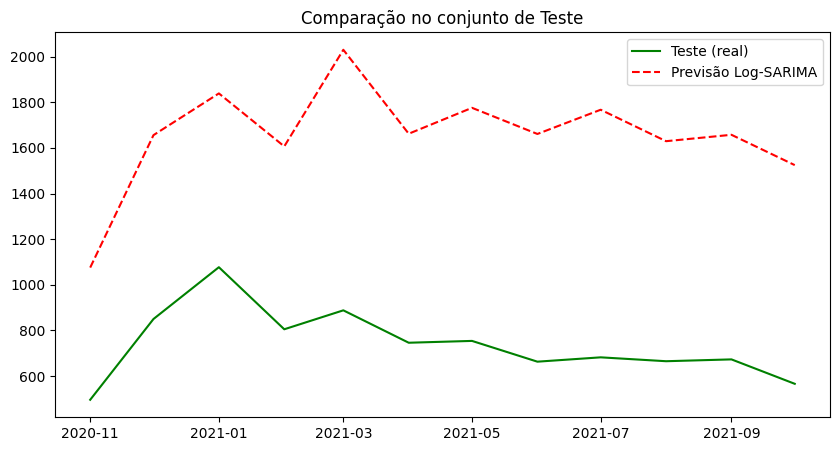

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Teste (real)', color='green')
plt.plot(test.index, forecast, label='Previsão Log-SARIMA', color='red', linestyle='--')
plt.title("Comparação no conjunto de Teste")
plt.legend()
plt.show()

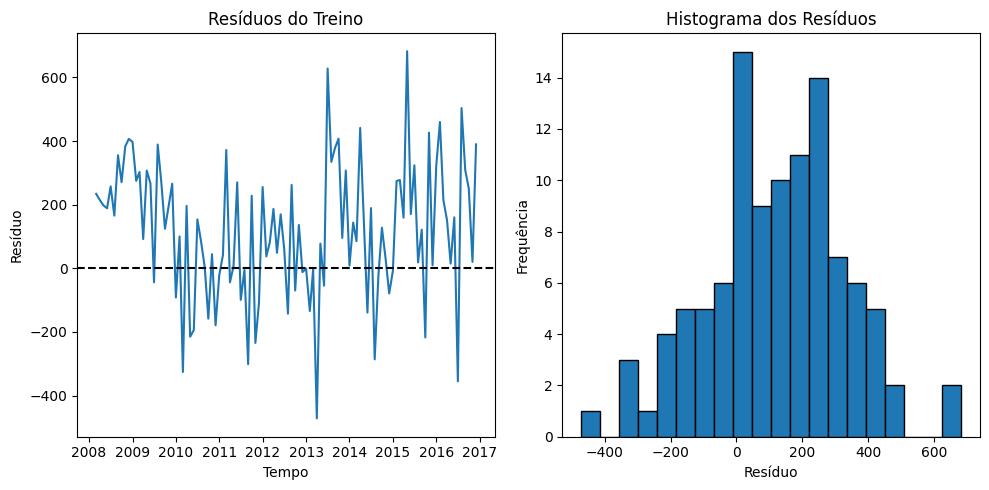

In [ ]:
# Resíduos ao longo do tempo
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(residuals)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Resíduos do Treino")
plt.xlabel("Tempo")
plt.ylabel("Resíduo")
# Histograma dos resíduos
plt.subplot(1,2,2)
plt.hist(residuals, bins=20, edgecolor="black")
plt.title("Histograma dos Resíduos")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

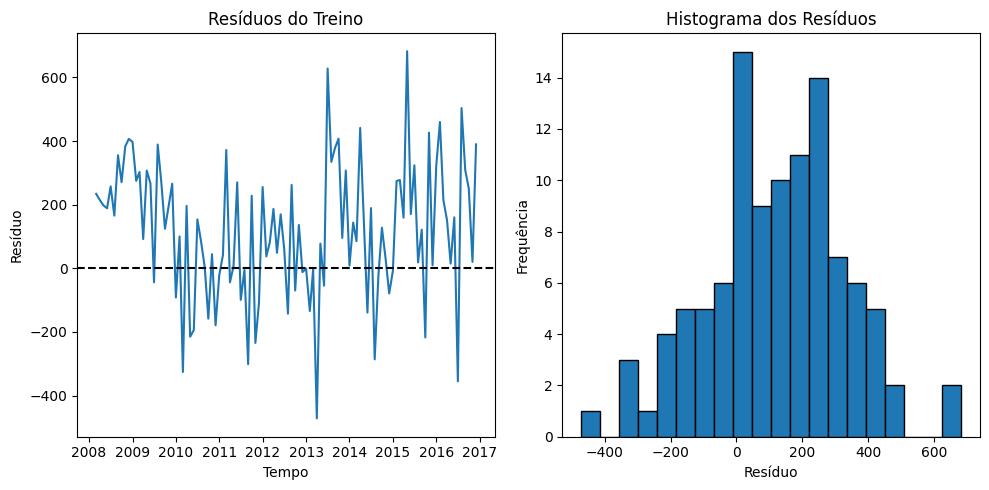

In [ ]:
# Resíduos ao longo do tempo
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(residuals)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Resíduos do Treino")
plt.xlabel("Tempo")
plt.ylabel("Resíduo")

# Histograma dos resíduos
plt.subplot(1,2,2)
plt.hist(residuals, bins=20, edgecolor="black")
plt.title("Histograma dos Resíduos")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [ ]:
# 1. Previsões no conjunto de TREINO
train_forecast_log = fit.predict(start=0, end=len(train_log)-1)
train_forecast = np.exp(train_forecast_log)

In [ ]:
test_forecast_log = fit.forecast(len(test))
test_forecast = np.exp(test_forecast_log)

In [ ]:
train_mse = mean_squared_error(train, train_forecast)
train_rmse = np.sqrt(train_mse)
train_mape = mean_absolute_percentage_error(train, train_forecast)


In [ ]:

# 4. Cálculo dos erros para TESTE
test_mse = mean_squared_error(test, test_forecast)
test_rmse = np.sqrt(test_mse)
test_mape = mean_absolute_percentage_error(test, test_forecast)


In [ ]:
print("=" * 50)
print("ERROS DE PREVISÃO - CONJUNTO DE TREINO")
print("=" * 50)
print(f"MSE:  {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAPE: {train_mape:.4f}")

print("\n" + "=" * 50)
print("ERROS DE PREVISÃO - CONJUNTO DE TESTE")
print("=" * 50)
print(f"MSE:  {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAPE: {test_mape:.4f}")


ERROS DE PREVISÃO - CONJUNTO DE TREINO
MSE:  752164.7036
RMSE: 867.2743
MAPE: 0.4143

ERROS DE PREVISÃO - CONJUNTO DE TESTE
MSE:  865437.9029
RMSE: 930.2892
MAPE: 1.2825


In [ ]:
# 8. Tabela resumo dos erros
print("\n" + "=" * 60)
print("RESUMO DOS ERROS DE PREVISÃO")
print("=" * 60)
print(f"{'Métrica':<10} {'Treino':<15} {'Teste':<15} {'Diferença':<15}")
print("-" * 60)
print(f"{'MSE':<10} {train_mse:<15.4f} {test_mse:<15.4f} {test_mse-train_mse:<15.4f}")
print(f"{'RMSE':<10} {train_rmse:<15.4f} {test_rmse:<15.4f} {test_rmse-train_rmse:<15.4f}")
print(f"{'MAPE':<10} {train_mape:<15.4f} {test_mape:<15.4f} {test_mape-train_mape:<15.4f}")


RESUMO DOS ERROS DE PREVISÃO
Métrica    Treino          Teste           Diferença      
------------------------------------------------------------
MSE        752164.7036     865437.9029     113273.1992    
RMSE       867.2743        930.2892        63.0149        
MAPE       0.4143          1.2825          0.8682         


### Machine Learning

In [ ]:
def create_supervised(series, n_lags=12, target_col="eventcount"):
    # Se for DataFrame, usa a primeira coluna
    if isinstance(series, pd.DataFrame):
        if series.shape[1] > 1:
            raise ValueError("Passe apenas uma coluna para create_supervised")
        colname = series.columns[0]
        df = series.rename(columns={colname: target_col}).copy()
    else:  # se for Series
        name = series.name if series.name is not None else target_col
        df = series.to_frame(name=target_col).copy()

    # Criar defasagens
    for i in range(1, n_lags+1):
        df[f'lag_{i}'] = df[target_col].shift(i)

    # Lags sazonais
    df['lag_24'] = df[target_col].shift(24)

    # Médias móveis
    df['rolling_mean_3'] = df[target_col].shift(1).rolling(3).mean()
    df['rolling_mean_6'] = df[target_col].shift(1).rolling(6).mean()

    return df.dropna()


In [ ]:
lags = 12
df_supervised = create_supervised(brserietotal.to_frame(), n_lags=lags)


In [ ]:
# Features sazonais
df_supervised["month"] = df_supervised.index.month
df_supervised["quarter"] = df_supervised.index.quarter
df_supervised["year"] = df_supervised.index.year

In [ ]:
X = df_supervised.drop('eventcount', axis=1)
y = df_supervised['eventcount']

In [ ]:
train_size = int(0.7 * len(X))
val_size   = int(0.15 * len(X))

In [ ]:
X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_val, y_val     = X.iloc[train_size:train_size+val_size], y.iloc[train_size:train_size+val_size]
X_test, y_test   = X.iloc[train_size+val_size:], y.iloc[train_size+val_size:]

train_idx = y_train.index
val_idx   = y_val.index
test_idx  = y_test.index

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None]
}


In [ ]:
grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error"
)

In [ ]:
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

In [ ]:
pred_train_rf = best_rf.predict(X_train)
pred_val_rf   = best_rf.predict(X_val)
pred_test_rf  = best_rf.predict(X_test)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# normalização
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [ ]:
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # saída regressão
])


In [ ]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    verbose=0
)


In [ ]:

# previsões
pred_train_nn = model.predict(X_train_scaled).ravel()
pred_val_nn   = model.predict(X_val_scaled).ravel()
pred_test_nn  = model.predict(X_test_scaled).ravel()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


## Avaliação

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

def evaluate(y_true, y_pred, nome):
    print(nome)
    print(" MSE :", mean_squared_error(y_true, y_pred))
    print(" MAPE:", mean_absolute_percentage_error(y_true, y_pred))
    print("-"*30)

In [ ]:
evaluate(y_train, pred_train_rf, "RF Treino")
evaluate(y_val,   pred_val_rf,   "RF Validação")
evaluate(y_test,  pred_test_rf,  "RF Teste")

evaluate(y_train, pred_train_nn, "NN Treino")
evaluate(y_val,   pred_val_nn,   "NN Validação")
evaluate(y_test,  pred_test_nn,  "NN Teste")

RF Treino
 MSE : 8968.782540638307
 MAPE: 0.11225216987031751
------------------------------
RF Validação
 MSE : 39284.497986067625
 MAPE: 0.1548958559507526
------------------------------
RF Teste
 MSE : 32365.586661432586
 MAPE: 0.21110326368619395
------------------------------
NN Treino
 MSE : 52986.703125
 MAPE: 0.22726009786128998
------------------------------
NN Validação
 MSE : 39141.07421875
 MAPE: 0.16771933436393738
------------------------------
NN Teste
 MSE : 65841.640625
 MAPE: 0.32275277376174927
------------------------------


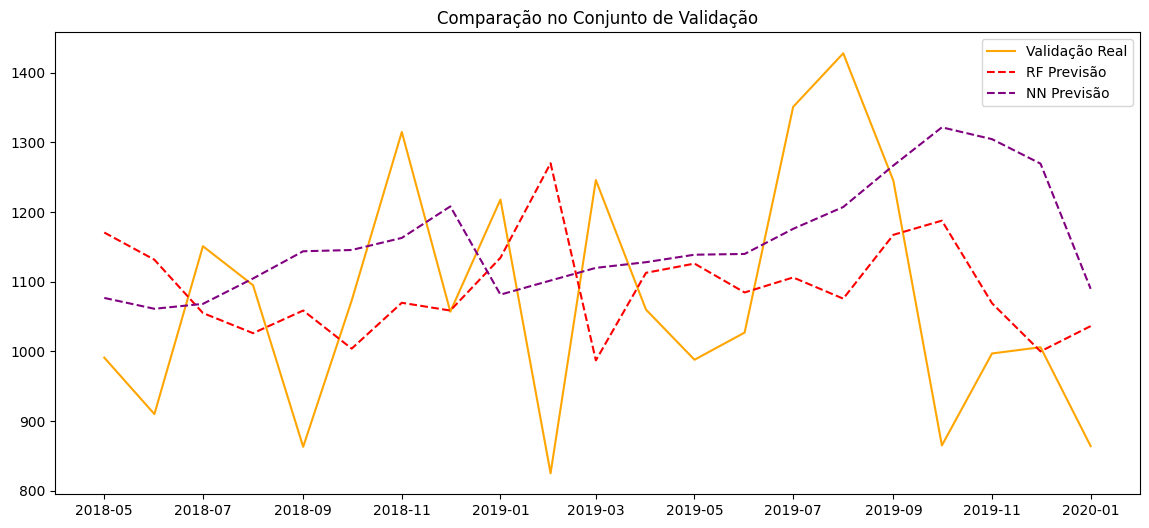

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_val.index, y_val, label="Validação Real", color="orange")
plt.plot(y_val.index, pred_val_rf, "--", label="RF Previsão", color="red")
plt.plot(y_val.index, pred_val_nn, "--", label="NN Previsão", color="purple")
plt.legend()
plt.title("Comparação no Conjunto de Validação")
plt.show()


# //////////////////// TESTE random forest e xgboooost

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from xgboost import XGBRegressor

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, X_te, y_te, idx_tr, idx_v, idx_te, name="Modelo"):
    preds_train = model.predict(X_tr)
    preds_val   = model.predict(X_v)
    preds_test  = model.predict(X_te)

    # --- Métricas ---
    mse_train = mean_squared_error(y_tr, preds_train)
    mse_val   = mean_squared_error(y_v, preds_val)
    mse_test  = mean_squared_error(y_te, preds_test)

    mape_train = mean_absolute_percentage_error(y_tr, preds_train)
    mape_val   = mean_absolute_percentage_error(y_v, preds_val)
    mape_test  = mean_absolute_percentage_error(y_te, preds_test)

    print(f"\n{name} - Resultados")
    print(f"Treino: MSE={mse_train:.2f}, MAPE={mape_train:.2%}")
    print(f"Val   : MSE={mse_val:.2f}, MAPE={mape_val:.2%}")
    print(f"Teste : MSE={mse_test:.2f}, MAPE={mape_test:.2%}")

    # --- Gráfico com escala temporal ---
    plt.figure(figsize=(14,6))

    # Concatena séries
    plt.plot(idx_tr, y_tr, label="Real - Treino", color="black")
    plt.plot(idx_tr, preds_train, label="Previsto - Treino", linestyle="--", color="blue")

    plt.plot(idx_v, y_v, label="Real - Validação", color="green")
    plt.plot(idx_v, preds_val, label="Previsto - Validação", linestyle="--", color="lightgreen")

    plt.plot(idx_te, y_te, label="Real - Teste", color="red")
    plt.plot(idx_te, preds_test, label="Previsto - Teste", linestyle="--", color="orange")

    plt.title(f"{name} - Previsão Temporal")
    plt.xlabel("Tempo (Ano-Mês)")
    plt.ylabel("EventCount")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)


In [ ]:

rf = RandomForestRegressor(random_state=42)


In [ ]:

# ---------------------------
# Random Forest
# ---------------------------
rf = RandomForestRegressor(random_state=42)
param_dist = {
    "n_estimators": [100, 200, 400],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", 0.5, 0.33],  # sqrt ou frações do total de features
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=60,                  # número de combinações a testar (ajuste conforme tempo)
    scoring="neg_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


In [ ]:

search.fit(X_train, y_train)  # X_train, y_train devem ser o bloco temporal inicial (sem val/test)
best_rf = search.best_estimator_
print("Best params:", search.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 10, 'bootstrap': False}



RandomForest - Resultados
Treino: MSE=11027.37, MAPE=10.71%
Val   : MSE=47488.66, MAPE=16.08%
Teste : MSE=41868.29, MAPE=23.59%


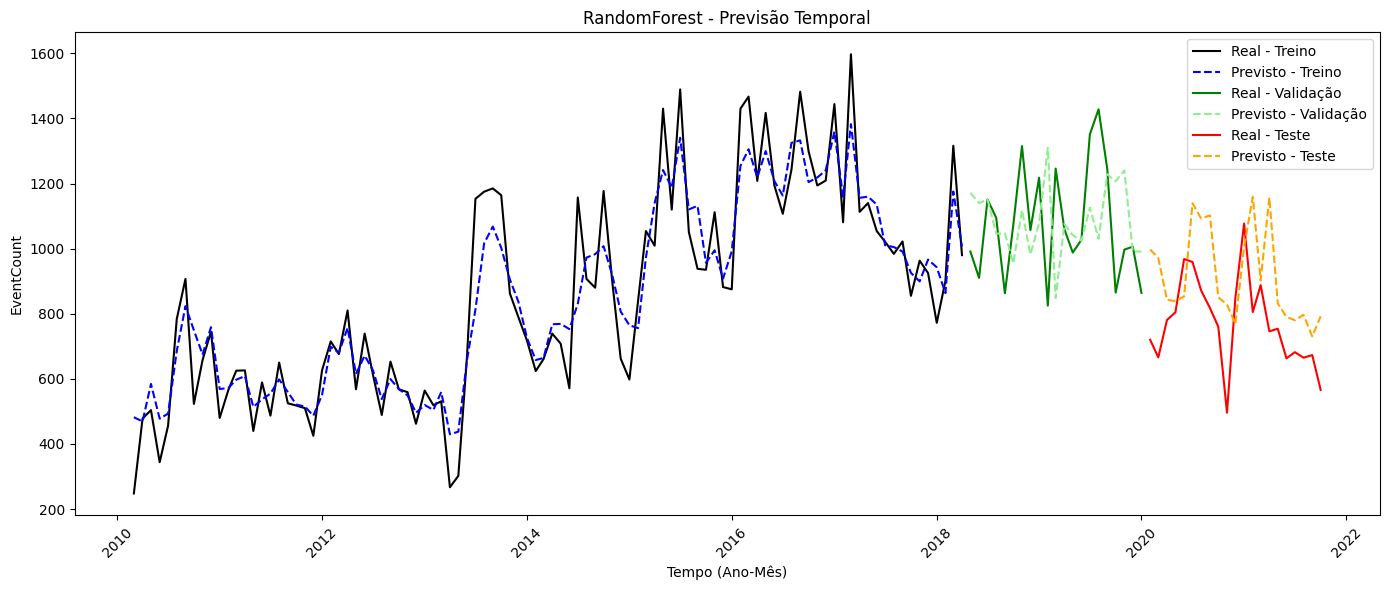

In [ ]:


# Avaliação com a função que você criou
evaluate_model(
    best_rf,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    train_idx, val_idx, test_idx,
    name="RandomForest"
)

Treino/val/teste equilibrado, MAPE de teste = 14.48% → levemente melhor que SVR em teste.

Modelo robusto, fácil de treinar.

In [ ]:
xgb = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)


In [ ]:
param_dist_xgb = {
    "n_estimators": [100, 300, 500, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 1, 5],
    "reg_lambda": [1, 5, 10]
}

In [ ]:
rand_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,                # apenas 50 combinações aleatórias
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [ ]:
rand_xgb.fit(X_train, y_train)


Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 300, 500, 800],
                                        'reg_alpha': [0, 0.1, 1, 5],
                                        'reg_lambda': [1, 5, 10],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
# ---------------------------
best_xgb = rand_xgb.best_estimator_
print("Melhores parâmetros encontrados:", rand_xgb.best_params_)

Melhores parâmetros encontrados: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 5, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}



XGBoost RandomSearch - Resultados
Treino: MSE=1.77, MAPE=0.08%
Val   : MSE=43609.01, MAPE=16.99%
Teste : MSE=31366.76, MAPE=20.35%


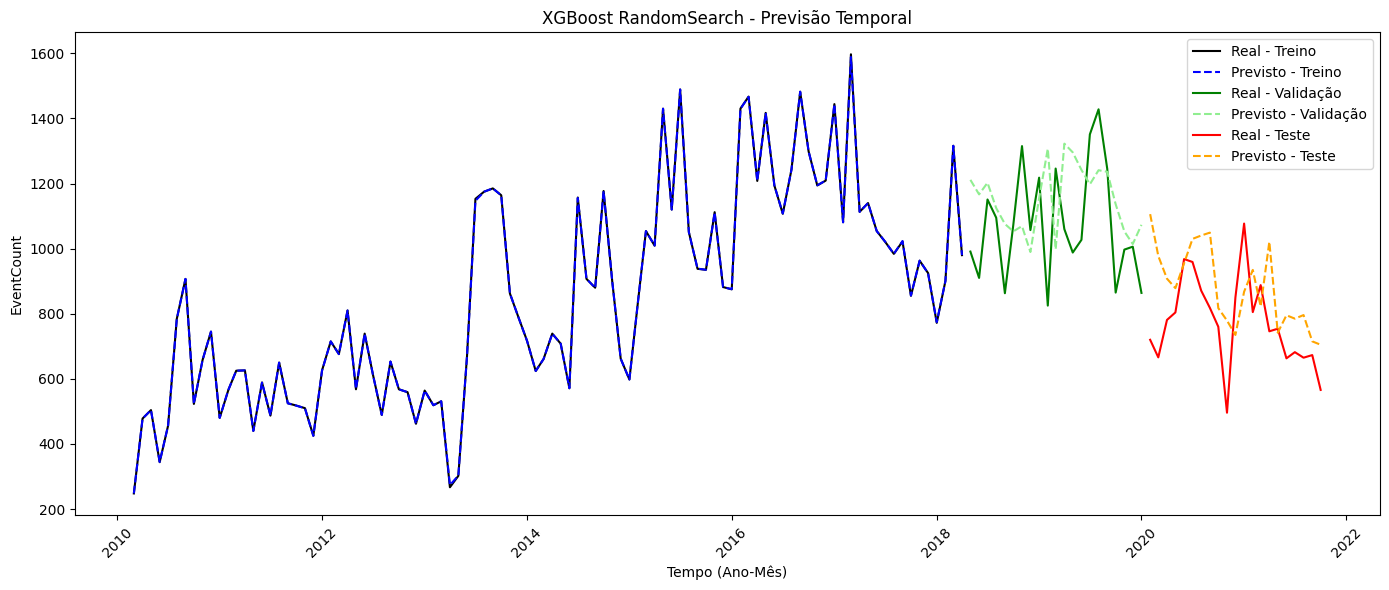

In [ ]:
evaluate_model(
    best_xgb,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    train_idx, val_idx, test_idx,
    name="XGBoost RandomSearch"
)

XGBoost:

Treino quase perfeito, mas ainda apresenta overfitting leve (treino MSE muito baixo vs validação/teste).

MAPE no teste = 20.35%, ainda maior que SVR e RandomForest.

Pode melhorar com mais features temporais ou menos complexidade nas árvores.

# SVR - versão oficial

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV



In [ ]:
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

param_grid_svr = {
    "svr__kernel": ["rbf", "linear", "poly"],
    "svr__C": [1, 10, 100, 500],
    "svr__gamma": ["scale", "auto"],
    "svr__degree": [2, 3]  # só usado se kernel=poly
}

In [ ]:
grid_svr = GridSearchCV(
    svr_pipeline,
    param_grid=param_grid_svr,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_svr.fit(X_train, y_train)

print("Melhores parâmetros:", grid_svr.best_params_)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Melhores parâmetros: {'svr__C': 10, 'svr__degree': 2, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}



SVR - Resultados
Treino: MSE=35461.69, MAPE=17.72%
Val   : MSE=39134.66, MAPE=15.07%
Teste : MSE=30456.37, MAPE=21.40%


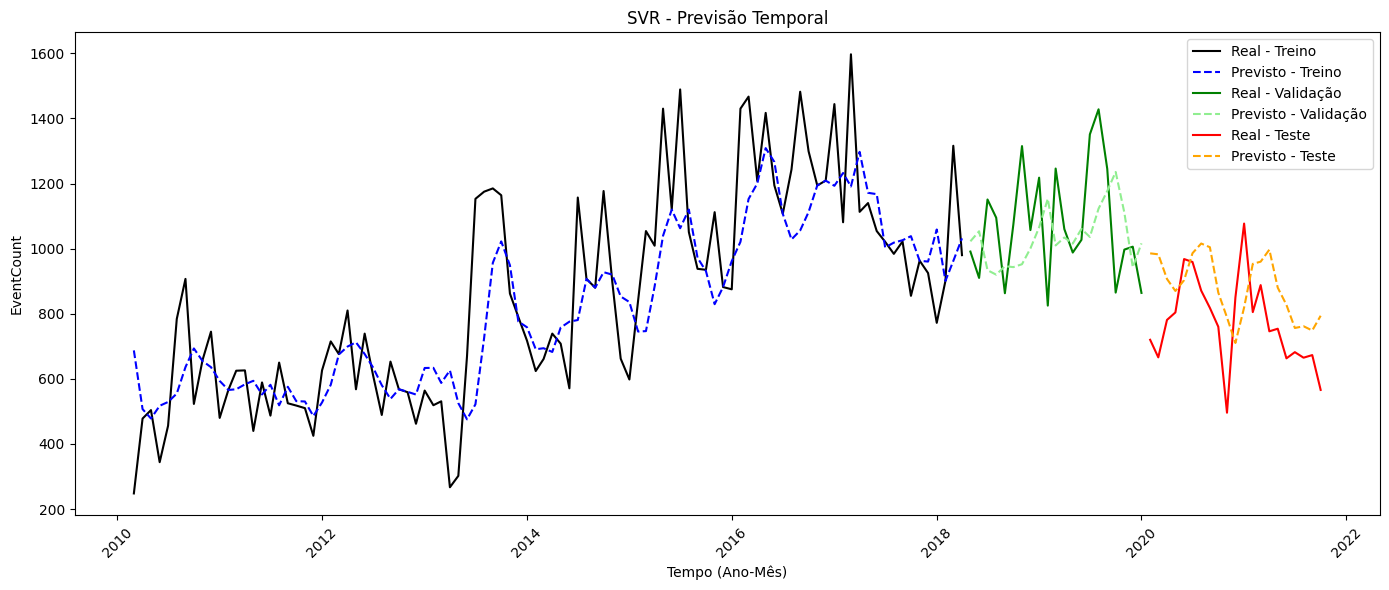

In [ ]:
best_svr = grid_svr.best_estimator_

evaluate_model(
    best_svr,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    train_idx, val_idx, test_idx,
    name="SVR"
)

In [ ]:
# === Previsões ===
preds_train = best_svr.predict(X_train)
preds_val   = best_svr.predict(X_val)
preds_test  = best_svr.predict(X_test)

# === Resíduos ===
res_train = pd.Series(y_train - preds_train, index=y_train.index)
res_val   = pd.Series(y_val - preds_val, index=y_val.index)
res_test  = pd.Series(y_test - preds_test, index=y_test.index)

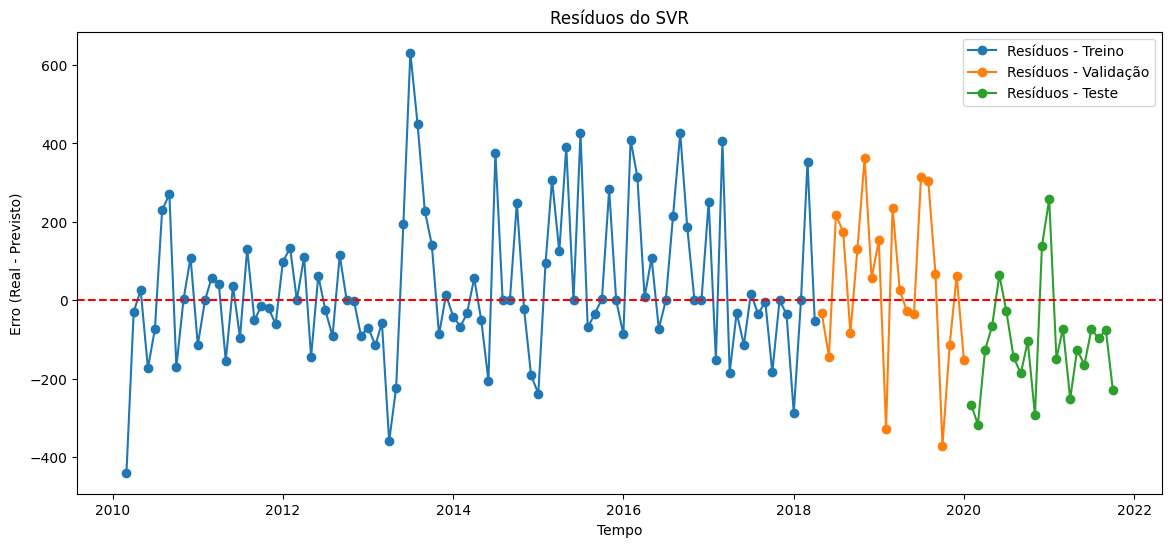

In [ ]:
# Garantir que y_train, y_val e y_test mantenham o índice de tempo original
res_train = pd.Series(y_train - preds_train, index=y_train.index)
res_val   = pd.Series(y_val - preds_val, index=y_val.index)
res_test  = pd.Series(y_test - preds_test, index=y_test.index)

plt.figure(figsize=(14,6))
plt.plot(res_train, label="Resíduos - Treino", marker='o')
plt.plot(res_val, label="Resíduos - Validação", marker='o')
plt.plot(res_test, label="Resíduos - Teste", marker='o')

plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos do SVR")
plt.xlabel("Tempo")
plt.ylabel("Erro (Real - Previsto)")
plt.legend()
plt.show()


SVR:

Mais consistente entre treino, validação e teste.

Teste MAPE = 15.53% → melhor generalização até agora.

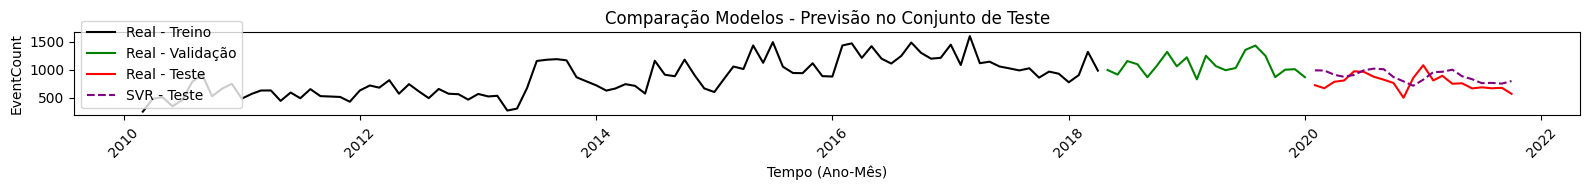

In [ ]:
plt.figure(figsize=(16,2))

# Valores reais
plt.plot(train_idx, y_train, label="Real - Treino", color="black")
plt.plot(val_idx, y_val, label="Real - Validação", color="green")
plt.plot(test_idx, y_test, label="Real - Teste", color="red")


# Previsões SVR
plt.plot(test_idx,  grid_svr.best_estimator_.predict(X_test), "--", label="SVR - Teste", color="purple")

plt.title("Comparação Modelos - Previsão no Conjunto de Teste")
plt.xlabel("Tempo (Ano-Mês)")
plt.ylabel("EventCount")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:


df_results = collect_results(
    [best_rf, best_xgb, best_svr],
    ["RandomForest", "XGBoost", "SVR"],
    X_train, y_train, X_val, y_val, X_test, y_test
)
print(df_results.sort_values("MAPE Validação"))



         Modelo    MSE Treino  MAPE Treino  MSE Validação  MAPE Validação  \
2           SVR  35461.694361     0.177227   39134.661889        0.150714   
0  RandomForest  11027.366012     0.107063   47488.655842        0.160773   
1       XGBoost      1.773820     0.000791   43609.011719        0.169920   

      MSE Teste  MAPE Teste  
2  30456.367541    0.213972  
0  41868.290092    0.235874  
1  31366.761719    0.203549  


In [ ]:


def collect_results(models, names, X_train, y_train, X_val, y_val, X_test, y_test):
    results = []
    for model, name in zip(models, names):
        preds_train = model.predict(X_train)
        preds_val   = model.predict(X_val)
        preds_test  = model.predict(X_test)

        mse_train = mean_squared_error(y_train, preds_train)
        mse_val   = mean_squared_error(y_val, preds_val)
        mse_test  = mean_squared_error(y_test, preds_test)

        mape_train = mean_absolute_percentage_error(y_train, preds_train)
        mape_val   = mean_absolute_percentage_error(y_val, preds_val)
        mape_test  = mean_absolute_percentage_error(y_test, preds_test)

        results.append([name, mse_train, mape_train, mse_val, mape_val, mse_test, mape_test])

    df_results = pd.DataFrame(results, columns=[
        "Modelo", "MSE Treino", "MAPE Treino",
        "MSE Validação", "MAPE Validação",
        "MSE Teste", "MAPE Teste"
    ])
    return df_results
    df_results = collect_results(
    [best_rf, best_xgb, best_svr],
    ["RandomForest", "XGBoost", "SVR"],
    X_train, y_train, X_val, y_val, X_test, y_test
)
print(df_results)


         Modelo    MSE Treino  MAPE Treino  MSE Validação  MAPE Validação  \
0  RandomForest  11027.366012     0.107063   47488.655842        0.160773   
1       XGBoost      1.773820     0.000791   43609.011719        0.169920   
2           SVR  35461.694361     0.177227   39134.661889        0.150714   

      MSE Teste  MAPE Teste  
0  41868.290092    0.235874  
1  31366.761719    0.203549  
2  30456.367541    0.213972  


In [ ]:
def plot_residuos(y_true, y_pred, idx, label):
    resid = y_true - y_pred
    plt.figure(figsize=(12,5))
    plt.plot(idx, resid, marker="o", label=f"Resíduos - {label}")
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Resíduos {label}")
    plt.xlabel("Tempo")
    plt.ylabel("Erro (Real - Previsto)")
    plt.legend()
    plt.show()
    return resid
pred_train_svr = best_svr.predict(X_train)
pred_val_svr   = best_svr.predict(X_val)
pred_test_svr  = best_svr.predict(X_test)


### Deep Learning - pendente

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from matplotlib.dates import DateFormatter


In [ ]:

def validation_loss(hidden_neurons):

    mlp = MLPRegressor(hidden_layer_sizes=(hidden_neurons,), max_iter=1000, random_state=1)

    mlp.fit(X_train, y_train)

    return mean_squared_error(y_test, mlp.predict(X_test))

In [ ]:

params = [10, 25, 50, 75, 100]
mse = [validation_loss(p) for p in params]

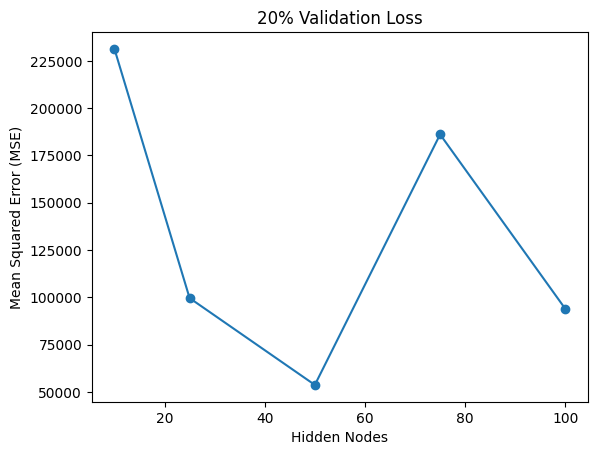

In [ ]:

fig, ax = plt.subplots()
plt.xlabel('Hidden Nodes')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('20% Validation Loss')
plt.plot(params, mse, '-o')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Ensure the create_supervised function is defined (copying from previous cell for single cell execution)
def create_supervised(series, n_lags=12, target_col="N Eventos"):
    # Convert input to DataFrame and set the target column name
    if isinstance(series, pd.Series):
        df = series.to_frame(name=target_col).copy()
    elif isinstance(series, pd.DataFrame) and series.shape[1] == 1:
        df = series.copy()
        df.columns = [target_col] # Ensure the single column is named target_col
    else:
         raise ValueError("Input must be a pandas Series or a single-column DataFrame")

    colname = target_col # Use the target_col name for creating lags


    # Criar defasagens
    for i in range(1, n_lags+1):
        df[f'lag_{i}'] = df[colname].shift(i)

    # Lags sazonais (assuming 24-hour seasonality as discussed)
    df['lag_12'] = df[colname].shift(12)

    # Médias móveis
    df['rolling_mean_3'] = df[colname].shift(1).rolling(3).mean()
    df['rolling_mean_6'] = df[colname].shift(1).rolling(6).mean()


    return df.dropna()


In [ ]:
brserietotal

,eventcount
Data,
2008-03-01,234
2008-04-01,320
2008-05-01,319
2008-06-01,308
2008-07-01,374
...,...
2021-06-01,663
2021-07-01,682
2021-08-01,665


In [ ]:
brserietotal.name

'eventcount'

In [ ]:
df_supervised_mlp.columns


Index(['N Eventos', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6',
       'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12',
       'rolling_mean_3', 'rolling_mean_6'],
      dtype='object')

In [ ]:


# Assuming 'serie' is already loaded and preprocessed (the 30-day series)
# Create supervised data for MLP
lags = 12 # Define the number of lags
df_supervised_mlp = create_supervised(brserietotal.to_frame(), n_lags=lags)

# Separate features (X) and target (y) from the supervised DataFrame for MLP
X_mlp = df_supervised_mlp.drop("N Eventos", axis=1)
y_mlp = df_supervised_mlp["N Eventos"]



# Split the supervised data for MLP into train and test sets
# Using a fixed split ratio as in previous cells (e.g., 80% train, 20% test)
# Adjust the split point based on the length of the supervised dataframe
n_mlp = len(df_supervised_mlp)
train_size_mlp = int(n_mlp * 0.5) # Example split
X_train_mlp, X_test_mlp = X_mlp.iloc[:train_size_mlp], X_mlp.iloc[train_size_mlp:]
y_train_mlp, y_test_mlp = y_mlp.iloc[:train_size_mlp], y_mlp.iloc[train_size_mlp:]



In [ ]:
print("Shapes of the MLP splits:")
print("X_train_mlp:", X_train_mlp.shape)
print("y_train_mlp:", y_train_mlp.shape)
print("X_test_mlp:", X_test_mlp.shape)
print("y_test_mlp:", y_test_mlp.shape)

Shapes of the MLP splits:
X_train_mlp: (76, 14)
y_train_mlp: (76,)
X_test_mlp: (76, 14)
y_test_mlp: (76,)


In [ ]:
# Define and train the MLP model
# You can adjust the hidden_layer_sizes, activation, solver, etc.
mlp_model = MLPRegressor(hidden_layer_sizes=(50, ),
                         activation='relu',
                         solver='adam',
                         max_iter=500,
                         random_state=42)

# Train the MLP model
mlp_model.fit(X_train_mlp, y_train_mlp)



MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)

In [ ]:
y_pred_test_mlp = mlp_model.predict(X_test_mlp)




In [ ]:
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae

mse_test_mlp = mse(y_test_mlp, y_pred_test_mlp)
mae_test_mlp = mae(y_test_mlp, y_pred_test_mlp)


In [ ]:

print(f"MLP Test MSE: {mse_test_mlp:.10f}")
print(f"MLP Test MAE: {mae_test_mlp:.10f}")


MLP Test MSE: 136829.2310553851
MLP Test MAE: 308.5991455022


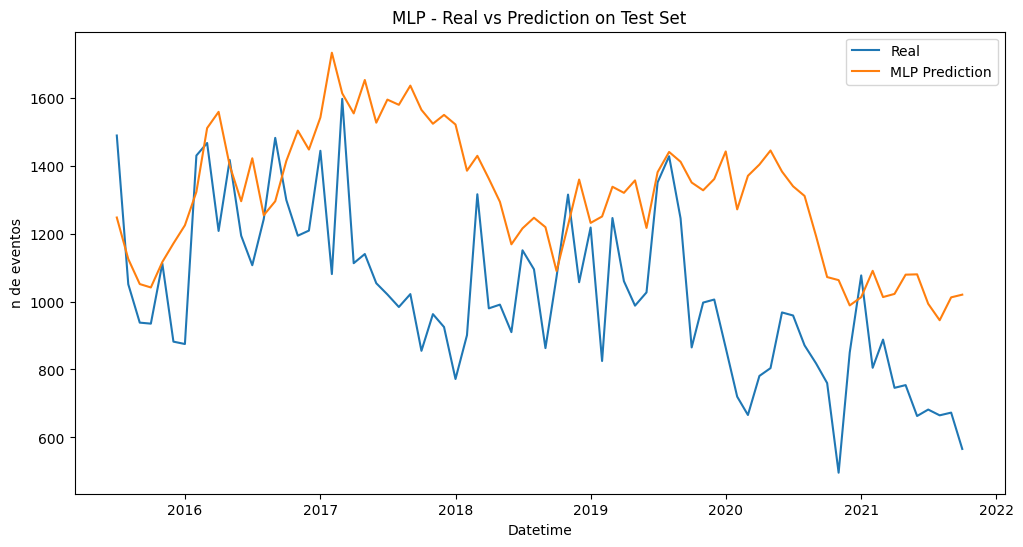

In [ ]:
# Plot the real vs MLP predictions on the test set
plt.figure(figsize=(12, 6))
plt.plot(y_test_mlp.index, y_test_mlp, label='Real')
plt.plot(y_test_mlp.index, y_pred_test_mlp, label='MLP Prediction')
plt.title("MLP - Real vs Prediction on Test Set")
plt.xlabel("Datetime")
plt.ylabel("n de eventos")
plt.legend()
plt.show()

In [ ]:
# --- 3️⃣ Cria dataset supervisionado para SVR (TREINO) ---
lags = 12
residuals_train_df = pd.DataFrame({"residual": residuals_train})

def create_supervised(series, lags=12):
    df = pd.DataFrame(series)
    for i in range(1, lags + 1):
        df[f"lag_{i}"] = df["residual"].shift(i)
    df = df.dropna()
    X = df.drop("residual", axis=1)
    y = df["residual"]
    return X, y

X_train_residual, y_train_residual = create_supervised(residuals_train_df, lags=lags)

# --- 4️⃣ Treina SVR nos resíduos do treino ---
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, gamma="scale"))
])
svr_pipeline.fit(X_train_residual, y_train_residual)

# --- 5️⃣ Previsão iterativa dos resíduos do teste ---
combined_residuals = residuals_train.tolist()  # últimos resíduos conhecidos
forecasted_residuals = []

for t in range(len(test)):
    last_res = combined_residuals[-lags:]
    X_input = pd.DataFrame([last_res], columns=[f"lag_{i}" for i in range(1, lags+1)])
    next_res = svr_pipeline.predict(X_input)[0]
    forecasted_residuals.append(next_res)
    combined_residuals.append(next_res)

forecasted_residuals = pd.Series(forecasted_residuals, index=test.index, name="predicted_residual")

# --- 6️⃣ Combina previsões SARIMA + SVR ---
hybrid_forecast = sarima_forecast_test + forecasted_residuals

# --- 7️⃣ Avaliação ---
mse_hybrid = mean_squared_error(test, hybrid_forecast)
mae_hybrid = mean_absolute_error(test, hybrid_forecast)
print("✅ Híbrido SARIMA + SVR (Iterativo)")
print(f"Test MSE: {mse_hybrid:.4f}")
print(f"Test MAE: {mae_hybrid:.4f}")

# --- 8️⃣ Visualização ---
plt.figure(figsize=(12, 4))
plt.plot(test.index, test, label="Real")
plt.plot(sarima_forecast_test.index, sarima_forecast_test, label="SARIMA")
plt.plot(hybrid_forecast.index, hybrid_forecast, label="Híbrido SARIMA + SVR")
plt.title("Previsões - SARIMA vs Híbrido")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.legend()
plt.show()

ValueError: Input contains NaN.

In [ ]:
print("Tamanho do teste:", len(test))
print("Número de lags:", lags)


In [ ]:
import pandas as pd
import numpy as np
import pmdarima as pm
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


# ============================================================
# 1️⃣ Função principal
# ============================================================
def hybrid_sarima_svr(train: pd.Series, test: pd.Series,
                      sarima_order=(1,0,0),
                      seasonal_order=(1,0,0,12),
                      lags=12,
                      C=100, gamma="scale"):
    """
    Modelo híbrido SARIMA + SVR iterativo para séries temporais curtas.

    Args:
        train, test: pd.Series com índices compatíveis
        sarima_order: parâmetros (p,d,q)
        seasonal_order: parâmetros sazonais (P,D,Q,s)
        lags: número de defasagens para o SVR
        C, gamma: hiperparâmetros do SVR

    Retorna:
        dict com previsões, métricas e objetos treinados
    """

    # ------------------------------------------------------------
    # 2️⃣ Treinar SARIMA
    # ------------------------------------------------------------
    sarima_model = pm.arima.ARIMA(order=sarima_order,
                                  seasonal_order=seasonal_order,
                                  suppress_warnings=True)
    sarima_model.fit(train)

    sarima_forecast_train = pd.Series(sarima_model.predict_in_sample(), index=train.index)
    sarima_forecast_test = pd.Series(sarima_model.predict(n_periods=len(test)), index=test.index)

    # ------------------------------------------------------------
    # 3️⃣ Calcular resíduos e preparar dados supervisionados
    # ------------------------------------------------------------
    residuals_train = train - sarima_forecast_train

    def create_supervised(series, lags=12):
        df = pd.DataFrame(series, columns=["residual"])
        for i in range(1, lags+1):
            df[f"lag_{i}"] = df["residual"].shift(i)
        df = df.dropna()
        X = df.drop("residual", axis=1)
        y = df["residual"]
        return X, y

    lags = min(lags, len(train) - 1)
    X_train_residual, y_train_residual = create_supervised(residuals_train, lags=lags)

    # ------------------------------------------------------------
    # 4️⃣ Treinar o SVR
    # ------------------------------------------------------------
    svr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=C, gamma=gamma))
    ])
    svr_pipeline.fit(X_train_residual, y_train_residual)

    # ------------------------------------------------------------
    # 5️⃣ Previsão iterativa dos resíduos
    # ------------------------------------------------------------
    forecasted_residuals = []
    combined_residuals = residuals_train.tolist()

    for t in range(len(test)):
        if len(combined_residuals) < lags:
            next_res = 0.0
        else:
            last_res = combined_residuals[-lags:]
            X_input = pd.DataFrame([last_res], columns=[f"lag_{i}" for i in range(1, lags+1)])
            next_res = svr_pipeline.predict(X_input)[0]
        forecasted_residuals.append(next_res)
        combined_residuals.append(next_res)

    forecasted_residuals = pd.Series(forecasted_residuals, index=test.index)
    hybrid_forecast = sarima_forecast_test + forecasted_residuals

    # Preenche NaNs iniciais com SARIMA puro
    hybrid_forecast = hybrid_forecast.fillna(sarima_forecast_test)

    # ------------------------------------------------------------
    # 6️⃣ Avaliação
    # ------------------------------------------------------------
    df_eval = pd.concat([test, hybrid_forecast], axis=1, keys=["real", "pred"]).dropna()
    mse_hybrid = mean_squared_error(df_eval["real"], df_eval["pred"])
    mae_hybrid = mean_absolute_error(df_eval["real"], df_eval["pred"])

    print("✅ Híbrido SARIMA + SVR (robusto)")
    print(f"Test MSE: {mse_hybrid:.4f}")
    print(f"Test MAE: {mae_hybrid:.4f}")
    print(f"Observações avaliadas: {len(df_eval)}")

    # ------------------------------------------------------------
    # 7️⃣ Visualização
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 4))
    plt.plot(df_eval.index, df_eval["real"], label="Real", linewidth=2)
    plt.plot(df_eval.index, sarima_forecast_test.loc[df_eval.index], label="SARIMA", linestyle="--")
    plt.plot(df_eval.index, df_eval["pred"], label="Híbrido SARIMA+SVR", linewidth=2)
    plt.title("Previsões - SARIMA vs Híbrido SARIMA+SVR")
    plt.xlabel("Data")
    plt.ylabel("Valor")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 8️⃣ Retorno
    # ------------------------------------------------------------
    return {
        "sarima_model": sarima_model,
        "svr_pipeline": svr_pipeline,
        "sarima_forecast_test": sarima_forecast_test,
        "hybrid_forecast": hybrid_forecast,
        "residuals_train": residuals_train,
        "metrics": {"MSE": mse_hybrid, "MAE": mae_hybrid}
    }





In [ ]:
# ============================================================
# 9️⃣ Exemplo de uso com sua série real (brserietotal)
# ============================================================

# --- Divide em treino e teste (ex: 80% treino, 20% teste)
split = int(len(brserietotal) * 0.8)
train = brserietotal[:split]
test = brserietotal[split:]

# --- Executa o modelo híbrido
results = hybrid_sarima_svr(train, test)

# --- Exibe métricas
print("\n📊 Métricas finais:")
print(results["metrics"])

# --- (Opcional) Acessar previsões
hybrid_forecast = results["hybrid_forecast"]
sarima_forecast = results["sarima_forecast_test"]

# --- (Opcional) Plotar comparação completa
plt.figure(figsize=(12, 4))
plt.plot(train.index, train, label="Treino", color="gray", alpha=0.6)
plt.plot(test.index, test, label="Teste Real", color="black")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA", linestyle="--")
plt.plot(hybrid_forecast.index, hybrid_forecast, label="Híbrido SARIMA+SVR", linewidth=2)
plt.title("Comparação completa - SARIMA vs Híbrido SARIMA+SVR")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("NaNs em test:", test.isna().sum())
print("NaNs em hybrid_forecast:", hybrid_forecast.isna().sum())
